# Gaby stuff


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia

/scratch/ascaffid/anaconda3/envs/lhc/lib/python3.9/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /u/a/ascaffid/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [13]:
# !wget https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits


--2026-02-16 11:14:11--  https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits
Resolving www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca (www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca)... 132.246.217.4
Connecting to www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca (www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca)|132.246.217.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits [following]
--2026-02-16 11:14:11--  https://ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits
Resolving ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca (ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca)... 132.246.217.29
Connecting to ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca (ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca)|132.246.217.29|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://ws-cadc.

In [9]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv

--2026-02-16 11:12:43--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4479 (4.4K) [text/plain]
Saving to: ‘candidate_1.csv’

candidate_1.csv     100%[===================>]   4.37K  --.-KB/s    in 0s      

2026-02-16 11:12:43 (34.9 MB/s) - ‘candidate_1.csv’ saved [4479/4479]



In [2]:
nearby = at.Table.read('/data/ascaffid/Dwarfs/gaia_ee/NearbyGalaxies_Jan2021_PUBLIC.fits')
nearby

GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References
bytes16,bytes10,bytes11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,bytes53
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,--,--,--,--,--,--,(14)(15)(99)
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,--,--,--,--,--,--,(1)(2)(95)(176)
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267)
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267)
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267)
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267)
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267)
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267)
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267)


In [3]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv

--2026-06-08 15:23:07--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4479 (4.4K) [text/plain]
Saving to: ‘candidate_1.csv.8’

candidate_1.csv.8   100%[===================>]   4.37K  --.-KB/s    in 0s      

2026-06-08 15:23:07 (22.0 MB/s) - ‘candidate_1.csv.8’ saved [4479/4479]



In [4]:
candi_wavelet = pd.read_csv('candidate_1.csv')
candi_wavelet

,Unnamed: 0,source_id,dec,ra,pmra,pmdec,pmra_error,pmdec_error,parallax,parallax_error,...,bp_g,bp_rp,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_rp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error
0,707,2.986320e+18,-15.366224,76.158490,0.305989,0.463938,0.250168,0.247735,0.030105,0.141417,...,0.314905,0.816984,1429.130462,1.743400,18.115591,784.005430,9.917649,17.298607,966.775231,8.805240
1,853,2.986320e+18,-15.391239,76.203888,-0.502617,0.020636,0.477368,0.508026,0.151568,0.264454,...,0.375025,0.896303,565.517251,1.221965,19.182276,293.524683,6.383181,18.285973,389.384849,6.909301
2,3719,2.986350e+18,-15.285426,76.205069,-0.173331,0.217779,0.269092,0.266138,0.177438,0.149482,...,0.459101,1.043344,1269.437558,1.755778,18.388437,609.789782,9.364026,17.345093,926.255181,8.886793
3,3948,2.986350e+18,-15.237817,76.180288,0.093763,0.308329,3.260364,3.172505,-0.053659,1.516647,...,-0.293985,0.743013,94.067071,0.969154,20.460787,90.415060,18.663846,19.717773,104.149801,7.367435
4,7864,2.986360e+18,-15.181419,76.179535,-0.245193,0.164555,0.467497,0.367329,-0.250238,0.214014,...,0.182331,0.532162,977.318640,10.509111,18.395607,605.776770,35.218843,17.863445,574.631657,22.067588
5,9649,2.986330e+18,-15.288533,76.149635,0.042995,1.036200,1.080197,1.104038,0.763687,0.623503,...,1.066671,2.287533,227.127177,1.371132,20.864365,62.346080,7.344862,18.576832,297.875918,8.418289
6,10179,2.986320e+18,-15.355357,76.143467,-0.109813,-0.288097,0.177802,0.167919,-0.109547,0.098951,...,0.103636,0.568594,3224.582789,10.081758,17.020817,2148.959232,28.160607,16.452223,2108.038364,21.165304
7,10369,2.986350e+18,-15.234326,76.221007,0.236942,0.706261,0.786018,0.817723,-0.245442,0.555737,...,0.313452,0.910501,228.212820,1.048401,20.105967,125.362772,7.311119,19.195465,168.493110,7.098917
8,10722,2.986330e+18,-15.315390,76.142538,0.390875,0.036680,0.131126,0.131355,0.160475,0.073566,...,0.439720,1.022944,4059.739220,3.046282,17.106840,1985.267303,12.455821,16.083897,2959.436689,8.556108
9,11209,2.986350e+18,-15.294294,76.299052,-0.398052,-0.161331,0.528215,0.511901,-0.366129,0.373213,...,0.451561,1.121254,467.608282,1.542330,19.465221,226.186319,7.294814,18.343967,369.131362,9.752962


In [131]:
## I am not too convinced that you can detect those candidates from the wavelet paper, I'm confused there's so few members?
## worth a shot ig


## Some known dwarfs galaxies 

In [17]:
# https://iopscience.iop.org/article/10.3847/1538-4357/ab7eb9 
# Confirmed and candidates:
# (Classifications are: (1) unconfirmed systems, (2) probable star clusters, (3) probable dwarfs, (4) kinematically confirmed dwarfs)
!wget https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt 
# this paper " recovered 18 out of 21 confirmed and candidate satellite galaxies in the DES footprint ; [..]
# recovered 20 of the 32 confirmed and candidate satellite galaxies known to reside in the PS1 DR1 footprint. 
# The lower recovery rate in PS1 is expected since many of the satellites in the PS1 footprint were discovered with significantly 
# deeper data. "

--2026-02-16 11:14:41--  https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt
Resolving content.cld.iop.org (content.cld.iop.org)... 108.157.194.31, 108.157.194.74, 108.157.194.98, ...
Connecting to content.cld.iop.org (content.cld.iop.org)|108.157.194.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9578 (9.4K) [text/plain]
Saving to: ‘apjab7eb9t2_mrt.txt’

apjab7eb9t2_mrt.txt 100%[===================>]   9.35K  --.-KB/s    in 0s      

2026-02-16 11:14:41 (110 MB/s) - ‘apjab7eb9t2_mrt.txt’ saved [9578/9578]



In [5]:
dwarfs =ascii.read('apjab7eb9t2_mrt.txt')

In [9]:
!cat apjab7eb9t2_mrt.txt

Title: Milky Way Satellite Census - I. The Observational Selection Function 
       for Milky Way Satellites in DES Y3 and Pan-STARRS DR1 
Authors: Drlica-Wagner A., Bechtol K., Mau S., McNanna M., Nadler E.O., 
         Pace A.B., Li T.S., Pieres A., Rozo E., Simon J.D., Walker A.R., 
         Wechsler R.H., Abbott T.M.C., Allam S., Annis J., Bertin E., 
         Brooks D., Burke D.L., Rosell A.C., Kind M.C., Carretero J., 
         Costanzi M., da Costa L.N., Vicente J.D., Desai S., Diehl H.T., 
         Doel P., Eifler T.F., Everett S., Flaugher B., Frieman J., 
         Garcia-Bellido J., Gaztanaga E., Gruen D., Gruendl R.A., Gschwend J.,
         Gutierrez G., Honscheid K., James D.J., Krause E., Kuehn K., 
         Kuropatkin N., Lahav O., Maia M.A.G., Marshall J.L., Melchior P., 
         Menanteau F., Miquel R., Palmese A., Plazas A.A., Sanchez E., 
         Scarpine V., Schubnell M., Serrano S., Sevilla-Noarbe I., 
         Smith M., Suchyta E., Tarle G. 
Table: Confirmed and 

In [15]:
len(dwarfs)

61

In [14]:
dwarf_name = 'Tucana II'
fornaxid = np.where(dwarfs['Class']==4)
len(dwarfs[fornaxid])

39

### SAME CUT AS WAVELET + ruwe

In [18]:
# probably relevant https://academic.oup.com/mnras/article/518/3/3746/6825500?login=true

In [ ]:
### square select

##Reduce the amount of features we get

## large parallax: closer
## We want smaller parallax but still good measurement ?




center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]

# Candidate 1
# center_ra, center_dec = 76.1691121, -15.29554739

degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 15 # lets ignore this cut

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND parallax - parallax_error * 3 < 0.0  \
AND ruwe < 1.4 )".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra <       RAdeg       
       deg        
------------------
          146.8868
          341.4813
            213.02
          212.5141
             212.3
          205.0091
          197.2927
          103.4065
          117.1066
          117.6298
               ...
           18.0183
          154.7504
          156.2628
16.186700000000002
          345.9796
              3.73
          161.7706
          135.8726
           230.242
          165.3436
Length = 39 rows AND ra >  RAdeg  
  deg   
--------
140.8868
335.4813
  207.02
206.5141
   206.3
199.0091
191.2927
 97.4065
111.1066
111.6298
     ...
 12.0183
148.7504
150.2628
 10.1867
339.9796
   -2.27
155.7706
129.8726
 224.242
159.3436
Length = 39 rows AND dec <         DEdeg       
        deg        
-------------------
           -33.7673
 -6.327400000000001
            17.5135
            15.8553
               29.8
            36.5521
  

(15929,)

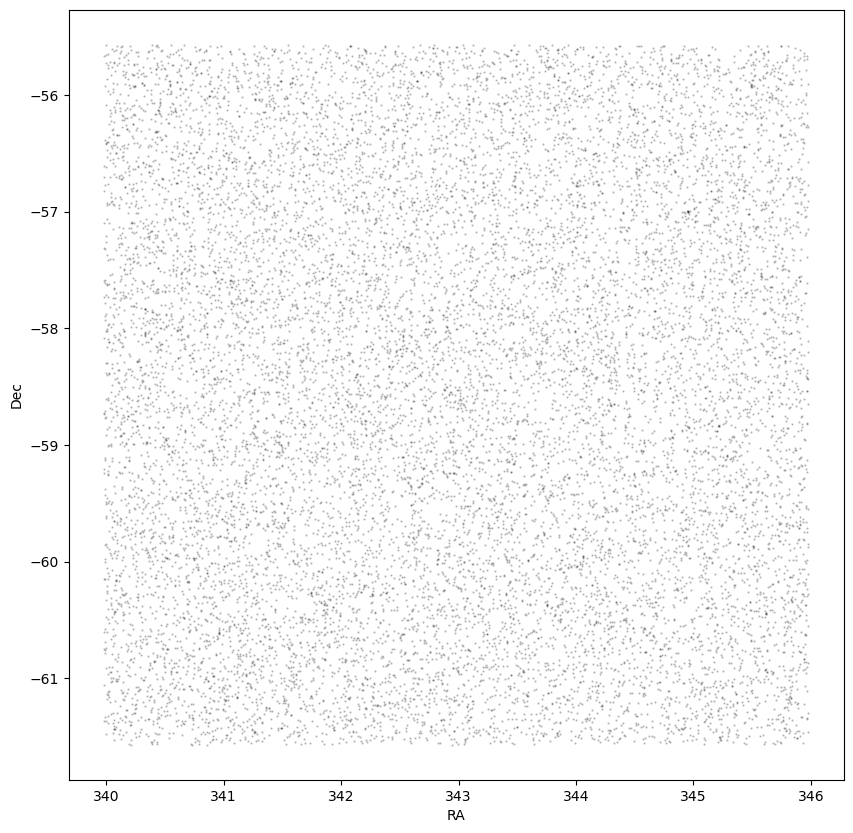

In [23]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')
r['ra'].shape

## Playing with other cuts

In [14]:
### square select

##Reduce the amount of features we get

center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]
degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 20 # Maybe this should be modified?

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND phot_g_mean_mag < {} \
AND parallax IS NOT NULL \
AND parallax < 1 \
AND parallax_over_error > 1 \
AND ruwe < 1.4 \
AND ebpminrp_gspphot IS NOT NULL)".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep,
                                         minmag)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra < 103.4065 AND ra > 97.4065 AND dec <  -47.9593 AND dec > -53.9593 AND pmra < 5 AND pmra > -5 AND pmdec > -5 AND pmdec < 5 AND phot_g_mean_mag < 20 AND parallax IS NOT NULL AND parallax < 1 AND parallax_over_error > 1 AND ruwe < 1.4 AND ebpminrp_gspphot IS NOT NULL)
INFO: Query finished. [astroquery.utils.tap.core]
5.8136372566223145
42876


Text(0, 0.5, 'Dec')

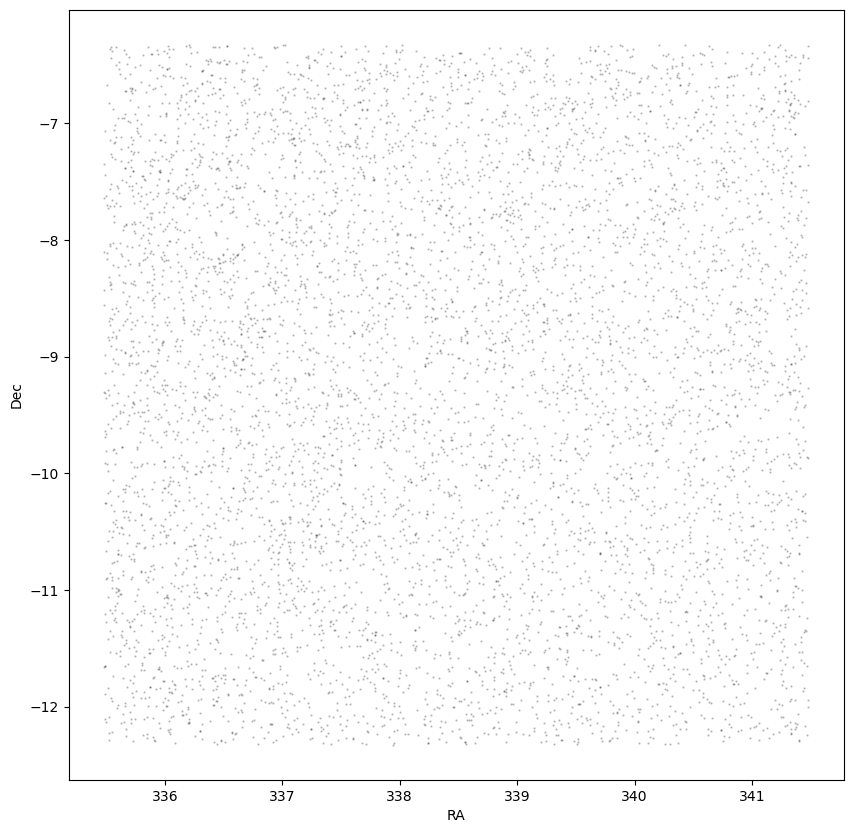

In [8]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')

In [ ]:
# query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
# WHERE (ra < {} \
# AND ra > {} \
# AND dec <  {} \
# AND dec > {} \
# AND phot_g_mean_mag < {} \
# AND parallax IS NOT NULL \
# AND parallax_over_error > 10.0  \
# AND ruwe < 1.4 \
# AND ebpminrp_gspphot IS NOT NULL)

In [ ]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord



In [ ]:
# Search for catalogs mentioning your dwarf galaxy
v = Vizier(columns=['**'], row_limit=-1)
catalogs = Vizier.find_catalogs('Carina gaia')

catalogs

OrderedDict([('I/324', </>),
             ('I/337', </>),
             ('I/345', </>),
             ('I/347', </>),
             ('I/350', </>),
             ('I/352', </>),
             ('I/355', </>),
             ('I/356', </>),
             ('I/357', </>),
             ('I/358', </>),
             ('I/359', </>),
             ('I/360', </>),
             ('I/361', </>),
             ('IV/36', </>),
             ('VI/137', </>),
             ('VI/145', </>),
             ('J/A+A/523/A48', </>),
             ('J/A+A/674/A25', </>)])

In [ ]:
# Once you identify the right catalog ID (e.g., 'J/ApJ/...')
result = v.get_catalogs(catalogs)
result

In [ ]:
result[0]

recno,HJD,Weight,RV(A),RV(B),res(A),res(B)
,d,,km / s,km / s,km / s,km / s
int32,float64,float32,float32,float32,float32,float32
1,2451144.83060,1.0,257.4,-279.8,-3.0,-2.0
2,2451145.84399,0.0,25.0,13.2,28.5,8.8
3,2451146.86755,1.0,-256.0,284.5,5.2,4.5
4,2451147.86649,0.0,-1.4,48.9,34.9,9.4
5,2451148.80902,1.0,247.7,-278.5,12.1,-1.4
6,2451149.87170,0.0,106.7,66.2,55.4,120.4
7,2451150.83746,1.0,-262.2,276.5,0.5,-5.1
8,2451152.73657,1.0,240.0,-275.1,-2.8,-16.1


In [ ]:
### Other option is a cone search but somehow it is super slow in some instances? 

# center_ra, center_dec = 76.16, -15.36
# degsep = 3

# ## This selects ALL features from gaia lite which is overkill
# query = "SELECT *,  DISTANCE( \
#    POINT({}, {}), \
#    POINT(ra, dec)) AS ang_sep \
# FROM gaiadr3.gaia_source_lite \
# WHERE 1 = CONTAINS( \
#    POINT({}, {}), \
#    CIRCLE(ra, dec, {})) \
# AND phot_g_mean_mag < 20 \
# AND parallax IS NOT NULL \
# AND parallax_over_error > 10.0  \
# AND ruwe < 1.4 \
# AND ebpminrp_gspphot IS NOT NULL".format(center_ra, center_dec, center_ra, center_dec, degsep)
# print(query)

# t= time.time()
# job = Gaia.launch_job_async(query)

# r = job.get_results()
# print(time.time()-t)

# Analysis

In [1]:
module_path = '/data/ascaffid/LHC_Olympics/EagleEye/eagleeye'
import sys
sys.path.append(module_path)
import EagleEye
from utils_EE import compute_the_null, partitioning_function
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia

/scratch/ascaffid/anaconda3/envs/lhc/lib/python3.9/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /u/a/ascaffid/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).



SELECT source_id, ra, dec, pmra, pmdec, phot_g_mean_mag, parallax, parallax_error, ruwe
FROM gaiadr3.gaia_source
WHERE
  (ra BETWEEN 95.4065 AND 105.4065)
  AND (dec BETWEEN -55.9593 AND -45.9593)
  AND pmra BETWEEN -5 AND 5
  AND pmdec BETWEEN -5 AND 5
  AND (parallax - 3*parallax_error) < 0.0

INFO: Query finished. [astroquery.utils.tap.core]
17.537665128707886
246257


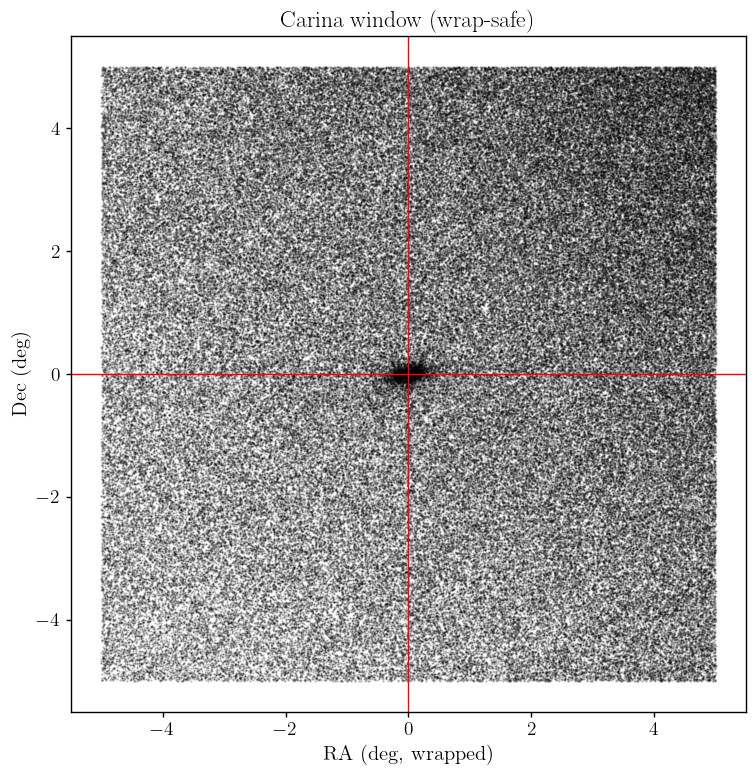

<class 'dict'>
{'med': array([0.06, 0.08, 0.09, 2.46]), 'mad': array([0.52, 0.83, 1.17, 1.49])}
Y shape: (28846, 4)
X_refs shapes: [(17164, 4), (20869, 4), (26217, 4), (21231, 4), (32919, 4), (25438, 4), (31344, 4), (42229, 4)]
Scaling med: [0.06 0.08 0.09 2.46]
Scaling mad: [0.52 0.83 1.17 1.49]


In [48]:

# RAN THESE DOWNLOADS SEPERATLY
# !wget https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits
# !wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv


candi_wavelet = pd.read_csv('candidate_2.csv')
candi_wavelet

nearby = at.Table.read('/data/ascaffid/Dwarfs/gaia_ee/NearbyGalaxies_Jan2021_PUBLIC.fits')
nearby

# https://iopscience.iop.org/article/10.3847/1538-4357/ab7eb9 
# Confirmed and candidates:
# (Classifications are: (1) unconfirmed systems, (2) probable star clusters, (3) probable dwarfs, (4) kinematically confirmed dwarfs)
# !wget https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt 
# this paper " recovered 18 out of 21 confirmed and candidate satellite galaxies in the DES footprint ; [..]
# recovered 20 of the 32 confirmed and candidate satellite galaxies known to reside in the PS1 DR1 footprint. 
# The lower recovery rate in PS1 is expected since many of the satellites in the PS1 footprint were discovered with significantly 
# deeper data. "

dwarfs =ascii.read('apjab7eb9t2_mrt.txt')


# Look at a dwarf
# dwarf_name = 'Bootes I'
dwarf_name = 'Carina'
# dwarf_name = 'Bootes I'

fornaxid = np.where(dwarfs['Name']==dwarf_name)[0][0]
dwarfs[fornaxid]

### square select

##Reduce the amount of features we get
def ra_condition(ra0, degsep):
    ra_min = (ra0 - degsep) % 360.0
    ra_max = (ra0 + degsep) % 360.0
    if ra_min <= ra_max:
        return f"(ra BETWEEN {ra_min} AND {ra_max})"
    else:
        # crosses 0
        return f"(ra >= {ra_min} OR ra <= {ra_max})"
## large parallax: closer
## We want smaller parallax but still good measurement ?


center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]

# # Candidate 1
# center_ra, center_dec = 76.1691121, -15.29554739

degsep = 5 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 10 # lets ignore this cut

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

ra_cut  = ra_condition(center_ra, degsep)
dec_cut = f"(dec BETWEEN {center_dec - degsep} AND {center_dec + degsep})"

query = f"""
SELECT source_id, ra, dec, pmra, pmdec, phot_g_mean_mag, parallax, parallax_error, ruwe
FROM gaiadr3.gaia_source
WHERE
  {ra_cut}
  AND {dec_cut}
  AND pmra BETWEEN -5 AND 5
  AND pmdec BETWEEN -5 AND 5
  AND (parallax - 3*parallax_error) < 0.0
"""

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))


import numpy as np
import matplotlib.pyplot as plt

def wrap_dra_deg(ra, ra0):
    """RA difference in degrees, wrapped to [-180, 180)."""
    return (ra - ra0 + 180.0) % 360.0 - 180.0

ra  = np.asarray(r['ra'], float)
dec = np.asarray(r['dec'], float)

# Compute wrapped offset from dwarf center
dra  = wrap_dra_deg(ra, center_ra)
ddec = dec - center_dec




plt.figure(figsize=(8,8))
plt.scatter(dra, ddec, s=0.5, alpha=0.2, c='k', rasterized=True)

plt.axvline(0, color='red', linewidth=1)
plt.axhline(0, color='red', linewidth=1)

plt.xlabel("RA (deg, wrapped)")
plt.ylabel("Dec (deg)")
plt.title(f"{dwarf_name} window (wrap-safe)")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Build Y and X_refs from a Gaia window split into a 3×3 grid,
# using LOCAL (cell-centered) coordinates for each cell, then applying ONE shared scaling
# (positions + velocities) fit from the TEST cell, so everything is on the same scale.



import numpy as np

def wrap_dra_deg(ra, ra0):
    """RA difference in degrees, wrapped to [-180, 180)."""
    return (ra - ra0 + 180.0) % 360.0 - 180.0

def split_into_3x3(ra, dec, ra0, dec0, cell_halfwidth_deg):
    """
    Same as your version: returns indices for test cell (center) and 8 surrounding refs.
    """
    h = float(cell_halfwidth_deg)
    dra  = wrap_dra_deg(np.asarray(ra, float), ra0)
    ddec = np.asarray(dec, float) - dec0

    ix = np.floor((dra + 3*h) / (2*h)).astype(int)
    iy = np.floor((ddec + 3*h) / (2*h)).astype(int)

    inside = (ix >= 0) & (ix < 3) & (iy >= 0) & (iy < 3)
    cell_id = np.full(len(dra), -1, dtype=int)
    cell_id[inside] = iy[inside] * 3 + ix[inside]  # 0..8

    test_id = 4
    ref_ids = [0, 1, 2, 3, 5, 6, 7, 8]

    out = {
        "cell_id": cell_id,
        "inside": inside,
        "test_idx": np.where(cell_id == test_id)[0],
        "ref_idx_list": [np.where(cell_id == rid)[0] for rid in ref_ids],
        "ref_ids": ref_ids,
    }
    return out

def robust_fit_mad(Z, eps=1e-12):
    """Robust center/scale using median and MAD (per feature)."""
    med = np.median(Z, axis=0)
    mad = np.median(np.abs(Z - med), axis=0)
    mad = np.where(mad < eps, 1.0, mad)
    return med, mad

def robust_apply(Z, med, mad):
    return (Z - med) / mad

def build_features_local_center(r, idx, ra_c, dec_c):
    """
    4D features comparable to wavelet:
      [dra*cos(dec_c), ddec, pmra, pmdec]
    with dra wrapped and multiplied by cos(dec_c).
    """
    ra    = np.asarray(r["ra"][idx], dtype=float)
    dec   = np.asarray(r["dec"][idx], dtype=float)
    pmra  = np.asarray(r["pmra"][idx], dtype=float)
    pmdec = np.asarray(r["pmdec"][idx], dtype=float)

    # dra  = wrap_dra_deg(ra, ra_c) * np.cos(np.deg2rad(dec_c))
    dra = wrap_dra_deg(ra, ra_c) * np.cos(np.deg2rad(dec0))  # constant across tiles
    ddec = dec - dec_c

    return np.column_stack([dra, ddec, pmra, pmdec]).astype(float)

def cell_center_from_id(ra0, dec0, cell_id, cell_halfwidth_deg):
    """
    Return (ra_center, dec_center) for a given 3×3 cell_id in {0..8},
    assuming global grid center is (ra0, dec0) and each cell has halfwidth h.

    Cell width = 2h.
    ix,iy in {0,1,2}; center offsets are (-2h, 0, +2h).
    """
    h = float(cell_halfwidth_deg)
    iy = cell_id // 3
    ix = cell_id % 3
    off = np.array([-2*h, 0.0, 2*h])
    ra_c  = ra0  + off[ix]
    dec_c = dec0 + off[iy]
    return ra_c, dec_c

def make_Xrefs_and_Y_from_window_3x3(
    r, ra0, dec0, cell_halfwidth_deg,
    fit_scaling_on="test",   # "test" recommended; alternatives: "all"
    do_robust_scale=True,
):
    """
    Returns:
      Y      : (nY,4) scaled features for test cell
      X_refs : list of 8 arrays, each (nXj,4) scaled features for ref cell j
      parts  : dict with indices + cell ids
      scale  : dict with med,mad used (or None if no scaling)
    """
    ra = np.asarray(r["ra"], float)
    dec = np.asarray(r["dec"], float)

    parts = split_into_3x3(ra, dec, ra0, dec0, cell_halfwidth_deg)
    test_idx = parts["test_idx"]
    ref_idx_list = parts["ref_idx_list"]
    ref_ids = parts["ref_ids"]

    # --- Build Y in local coords centered on TEST cell center (ra0,dec0) ---
    Y_raw = build_features_local_center(r, test_idx, ra0, dec0)

    # --- Build each reference in its OWN local coords centered on its own cell center ---
    X_refs_raw = []
    for rid, idx in zip(ref_ids, ref_idx_list):
        ra_c, dec_c = cell_center_from_id(ra0, dec0, rid, cell_halfwidth_deg)
        X_refs_raw.append(build_features_local_center(r, idx, ra_c, dec_c))

    # --- Fit scaling (positions + velocities) so refs are on the SAME scale as the test ---
    scale = {"med": None, "mad": None}
    if do_robust_scale:
        if fit_scaling_on == "test":
            Z_fit = Y_raw
        elif fit_scaling_on == "all":
            Z_fit = np.vstack([Y_raw] + X_refs_raw)
        else:
            raise ValueError("fit_scaling_on must be 'test' or 'all'.")

        med, mad = robust_fit_mad(Z_fit)
        scale = {"med": med, "mad": mad}

        Y = robust_apply(Y_raw, med, mad)
        X_refs = [robust_apply(Xj, med, mad) for Xj in X_refs_raw]
    else:
        Y = Y_raw
        X_refs = X_refs_raw

    return Y, X_refs, parts, scale


# -----------------------
# Example usage
# -----------------------
ra0, dec0 = center_ra, center_dec
cell_halfwidth_deg = degsep / 3.0   # so the center cell is your old ROI

Y, X_refs, parts, scale = make_Xrefs_and_Y_from_window_3x3(
    r, ra0, dec0, cell_halfwidth_deg,
    fit_scaling_on="all",
    do_robust_scale=True,
)

print(type(scale))
print(scale)

print("Y shape:", Y.shape)
print("X_refs shapes:", [Xj.shape for Xj in X_refs])
print("Scaling med:", scale["med"])
print("Scaling mad:", scale["mad"])

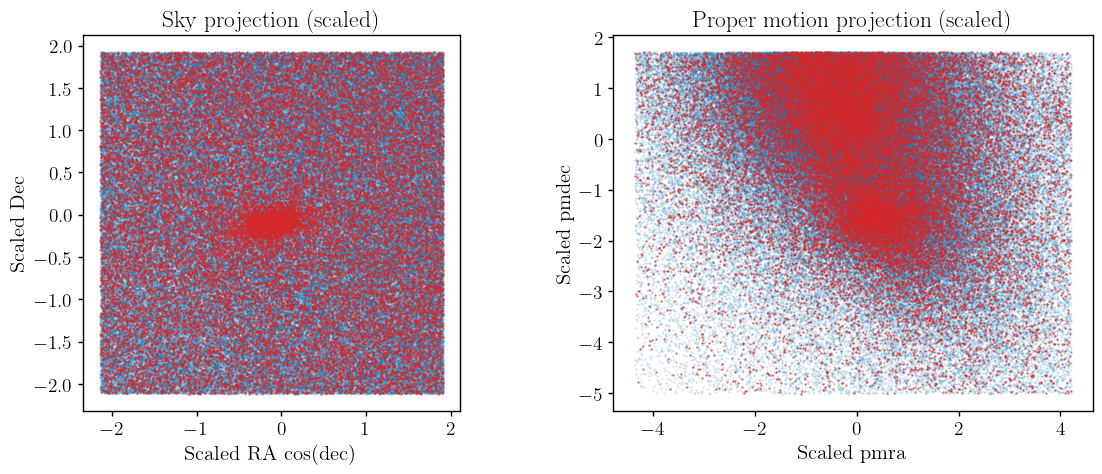

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =========================
# SKY PROJECTION
# =========================
ax = axes[0]

# references
for Xj in X_refs:
    ax.scatter(Xj[:,0], Xj[:,1],
               s=0.5, alpha=0.15, color='tab:blue', rasterized=True)

# test
ax.scatter(Y[:,0], Y[:,1],
           s=0.5, alpha=0.6, color='tab:red', rasterized=True)

ax.set_xlabel("Scaled RA cos(dec)")
ax.set_ylabel("Scaled Dec")
ax.set_title("Sky projection (scaled)")
ax.set_aspect('equal')

# =========================
# PROPER MOTION
# =========================
ax = axes[1]

for Xj in X_refs:
    ax.scatter(Xj[:,2], Xj[:,3],
               s=0.5, alpha=0.15, color='tab:blue', rasterized=True)

ax.scatter(Y[:,2], Y[:,3],
           s=0.5, alpha=0.6, color='tab:red', rasterized=True)

ax.set_xlabel("Scaled pmra")
ax.set_ylabel("Scaled pmdec")
ax.set_title("Proper motion projection (scaled)")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## EagleEye

In [51]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed

def _compute_the_null_worker(args):
    """
    Top-level worker so it is picklable.
    """
    j, p_j, K_M, N = args
    from utils_EE import compute_the_null  # import inside worker for subprocess
    stats_null_j = compute_the_null(p=p_j, K_M=K_M, N=N)
    return j, float(p_j), stats_null_j


def compute_the_null_multi_refs(p_list, K_M, N=500_000, n_jobs=8):
    """
    Parallel multi-reference wrapper around utils_EE.compute_the_null.

    Parameters
    ----------
    p_list : list[float]
        p_j = n_Y/(n_Y+n_Xj) per reference.
    K_M : int
    N : int
    n_jobs : int

    Returns
    -------
    stats_null_multi : dict
      {
        "p_list": [...],
        "K_M": K_M,
        "N": N,
        "by_ref": {
            j: {"p": p_j, "stats_null": {...}},
            ...
        }
      }
    """
    p_list = list(map(float, p_list))
    tasks = [(j, p_j, int(K_M), int(N)) for j, p_j in enumerate(p_list)]

    by_ref = {}
    max_workers = min(int(n_jobs), len(tasks)) if tasks else 1

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_compute_the_null_worker, t) for t in tasks]
        for fut in as_completed(futures):
            j, p_j, stats_null_j = fut.result()
            by_ref[j] = {"p": p_j, "stats_null": stats_null_j}

    return {"p_list": p_list, "K_M": K_M, "N": N, "by_ref": by_ref}




## p_ext

In [ ]:
p_list = [len(Y) / (len(Y) + len(Xj)) for Xj in X_refs]
kM = 300 # Keep about 10% of size of ref ant test ~400 for candidate 1
p_ext = 1E-5

stats_null_multi = compute_the_null_multi_refs(
    p_list=p_list,
    K_M=kM,
    N=200000,
    n_jobs=8
)

# Save srtats null multi to pickle
import pickle
with open("stats_null_multi_carina.pkl", "wb") as f:
    pickle.dump(stats_null_multi, f)

# RERUN ABOVE I USING NEW KM
# Load stats null multi from pickle
# import pickle
# with open("stats_null_multi_carina.pkl", "rb") as f:
#     stats_null_multi = pickle.load(f)

In [53]:
upsilonsS = []
for j, p_j in enumerate(p_list):
    null_array_j = stats_null_multi["by_ref"][j]["stats_null"][p_j]
    
    Gamma_star_j = np.quantile(
        null_array_j,
        1 - p_ext,
        method="higher"
    )
    upsilonsS.append(Gamma_star_j)
    print(f"Reference {j}: Gamma_star_j = {Gamma_star_j}")


Reference 0: Gamma_star_j = 14.832373292748999
Reference 1: Gamma_star_j = 14.70221812074091
Reference 2: Gamma_star_j = 13.615372280097006
Reference 3: Gamma_star_j = 14.94478610204124
Reference 4: Gamma_star_j = 13.677561994883584
Reference 5: Gamma_star_j = 14.36203067926173
Reference 6: Gamma_star_j = 13.100514419821423
Reference 7: Gamma_star_j = 14.352860526493476


In [54]:
import numpy as np
import EagleEye
from utils_EE import partitioning_function
from EagleEye import S_rootB_estimate_Y_overdensities, B_estimate_Y_overdensities

def compute_Gamma_i_multi_ref_with_SrootB(
    X_refs, Y,
    stats_null_multi,
    K_M=500,
    p_ext=1e-5,
    n_jobs=8,
    Z=2.65,
    upsilon_key="Upsilon_i_Y",
):
    R = len(X_refs)
    nY = len(Y)

    Upsilon_by_ref = np.zeros((R, nY), float)
    result_dicts   = []
    EE_books       = []
    SrootB_by_ref  = []
    B_by_ref       = []   # <-- NEW

    for j, Xj in enumerate(X_refs):
        stats_null_j = stats_null_multi["by_ref"][j]["stats_null"]

        # 1) Soar
        rd, _ = EagleEye.Soar(
            Xj, Y,
            K_M=K_M,
            p_ext=p_ext,
            n_jobs=n_jobs,
            stats_null=stats_null_j,
            result_dict_in={},
            do_IDE=True
        )

        if upsilon_key not in rd:
            raise KeyError(f"Ref {j}: missing '{upsilon_key}'. Keys: {list(rd.keys())}")

        ups = np.asarray(rd[upsilon_key], float)
        if ups.shape != (nY,):
            raise ValueError(f"Ref {j}: {upsilon_key} shape {ups.shape}, expected {(nY,)}")

        Upsilon_by_ref[j] = ups
        result_dicts.append(rd)

        # 2) Cluster
        clusters = partitioning_function(Xj, Y, rd, p_ext=p_ext, Z=Z)

        # 3) Repechage
        EE_book = EagleEye.Repechage(Xj, Y, rd, clusters, p_ext=p_ext)
        EE_books.append(EE_book)

        # 4a) s/sqrt(B)
        srb = S_rootB_estimate_Y_overdensities(rd, EE_book)
        SrootB_by_ref.append(srb)

        # 4b) B-hat (your new function)
        bhat = B_estimate_Y_overdensities(rd, EE_book)
        B_by_ref.append(bhat)

        # ---- Print cluster sizes + s/sqrt(B) + B-hat ----
        over_clusters = EE_book.get("Y_OVER_clusters", {})
        if isinstance(over_clusters, dict) and len(over_clusters) > 0:
            print(f"[ref {j}] Y_OVER_clusters: {len(over_clusters)}")
            for cid in sorted(over_clusters.keys()):
                rep = np.asarray(over_clusters[cid].get("Repechaged", []), dtype=int)
                bg  = np.asarray(over_clusters[cid].get("Background", []), dtype=int)
                pr  = np.asarray(over_clusters[cid].get("Pruned", []), dtype=int)

                srootb_c = srb.get("s/root(B)", {}).get(cid, np.nan)
                Bhat_c   = bhat.get("B", {}).get(cid, np.nan)
                ups_min  = srb.get("Upsilon_alpha_plus", {}).get(cid, np.nan)

                print(
                    f"  cluster {cid}: "
                    f"|Rep|={rep.size:4d}, |Bg|={bg.size:4d}, |Pr|={pr.size:4d} "
                    f" -> B̂={Bhat_c:.2f}, s/√B={srootb_c:.3f}, min(Upsilon)={ups_min:.3f}"
                )
        else:
            print(f"[ref {j}] Y_OVER_clusters: 0")

        print(f"[ref {j}] Total: "
              f"B̂={bhat.get('B', {}).get('Total', np.nan):.2f}, "
              f"s/√B={srb.get('s/root(B)', {}).get('Total', np.nan):.3f}")

    Gamma_i = np.sum(Upsilon_by_ref, axis=0)

    return {
        "Gamma_i": Gamma_i,
        "Upsilon_by_ref": Upsilon_by_ref,
        "result_dicts": result_dicts,
        "EE_books": EE_books,
        "SrootB_by_ref": SrootB_by_ref,
        "B_by_ref": B_by_ref,          # <-- NEW
        "p_ext": p_ext,
        "K_M": K_M,
        "Z": Z,
        "upsilon_key": upsilon_key,
    }


# Example call
out = compute_Gamma_i_multi_ref_with_SrootB(
    X_refs=X_refs,
    Y=Y,
    stats_null_multi=stats_null_multi,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    Z=2.65,
    upsilon_key="Upsilon_i_Y"
)

Gamma_i        = out["Gamma_i"]
B_by_ref       = out["B_by_ref"]
SrootB_by_ref  = out["SrootB_by_ref"]
EE_books       = out["EE_books"]
result_dicts   = out["result_dicts"]

-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 21.73 %
KNN completed: 43.47 %
KNN completed: 65.20 %
KNN completed: 86.94 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

'DONE!'

<IPython.core.display.Math object>

alpha = 1


'DONE!'

[ref 7] Y_OVER_clusters: 1
  cluster 0: |Rep|=3394, |Bg|=1352, |Pr|=2084  -> B̂=1950.20, s/√B=32.694, min(Upsilon)=15.978
[ref 7] Total: B̂=1950.20, s/√B=32.694


In [55]:
# Bootstrat emperical null
import numpy as np

def bootstrap_gamma_null_uniform(
    X_refs, Y,
    stats_null_multi,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    upsilon_key="Upsilon_i_Y",
    n_boot=50,
    seed=0,
):
    """
    Bootstrap an empirical null for Gamma_i by rerunning your *exact* multi-ref pipeline
    on Uniform([0,1]^d) vs Uniform([0,1]^d), matching the cardinalities of your real data.

    For each bootstrap b:
      - Generate Yb ~ Unif([0,1]^d) with len(Y) points
      - Generate each Xb_j ~ Unif([0,1]^d) with len(X_refs[j]) points
      - Call compute_Gamma_i_multi_ref(...) using the *same* stats_null_multi
      - Store Gamma_i^(b)

    Returns
    -------
    Gamma_null : np.ndarray, shape (n_boot, len(Y))
        Empirical null draws of the full pointwise Gamma_i vector.
    """
    rng = np.random.default_rng(seed)

    n_refs = len(X_refs)
    nY = len(Y)
    d = Y.shape[1]

    nX_list = [Xj.shape[0] for Xj in X_refs]

    Gamma_null = np.zeros((n_boot, nY), dtype=float)

    for b in range(n_boot):
        # generate null data with same cardinalities and same feature dimension
        Yb = rng.random((nY, d)).astype(float)
        Xb_refs = [rng.random((nX, d)).astype(float) for nX in nX_list]

        Gamma_b = compute_Gamma_i_multi_ref_with_SrootB(
            X_refs=Xb_refs,
            Y=Yb,
            stats_null_multi=stats_null_multi,
            K_M=K_M,
            p_ext=p_ext,
            n_jobs=n_jobs,
            upsilon_key=upsilon_key,
        )

        Gamma_null[b] = Gamma_b['Gamma_i']

        if (b + 1) % max(1, n_boot // 10) == 0:
            print(f"bootstrap {b+1}/{n_boot} done")

    return Gamma_null


def flatten_gamma_null(Gamma_null, finite_only=True):
    """
    Convenience: flatten bootstraps into one long 1D sample for quantiles/histograms.
    """
    g = Gamma_null.reshape(-1)
    if finite_only:
        g = g[np.isfinite(g)]
    return g


# -------------------------
# Example usage
# -------------------------
Gamma_null_mat = bootstrap_gamma_null_uniform(
    X_refs=X_refs, Y=Y,
    stats_null_multi=stats_null_multi,
    K_M=kM, p_ext=p_ext, n_jobs=100,
    upsilon_key="Upsilon_i_Y",
    n_boot=1,
    seed=42,
)



-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 21.73 %
KNN completed: 43.47 %
KNN completed: 65.20 %
KNN completed: 86.94 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

<IPython.core.display.Math object>

alpha = 1


'DONE!'

[ref 7] Y_OVER_clusters: 1
  cluster 0: |Rep|=   0, |Bg|=   0, |Pr|=   0  -> B̂=nan, s/√B=nan, min(Upsilon)=nan
[ref 7] Total: B̂=0.00, s/√B=nan
bootstrap 1/1 done


/data/ascaffid/LHC_Olympics/EagleEye/eagleeye/EagleEye.py:698: RuntimeWarning: invalid value encountered in scalar divide
  S_B = S_B / np.sqrt((lenBo *  (n2 - lenWo)/ (n1 - lenWu)))


In [56]:
import numpy as np
import numpy as np



def _pruned_dict_to_mask(pruned_dict, nY):
    mask = np.zeros(nY, dtype=bool)
    if pruned_dict is None:
        return mask

    if isinstance(pruned_dict, dict):
        if len(pruned_dict) == 0:
            return mask
        idxs = []
        for v in pruned_dict.values():
            if v is None:
                continue
            idxs.extend(list(v))
        if len(idxs) == 0:
            return mask
        idxs = np.asarray(idxs, dtype=int)
        idxs = idxs[(idxs >= 0) & (idxs < nY)]
        mask[idxs] = True
        return mask

    idxs = np.asarray(list(pruned_dict), dtype=int)
    if idxs.size == 0:
        return mask
    idxs = idxs[(idxs >= 0) & (idxs < nY)]
    mask[idxs] = True
    return mask


def combine_multi_ref_pruning(
    result_dicts,
    nY,
    p_ext=1e-5,
    upsilon_key="Upsilon_i_Y",
    pruned_key="Y_Pruned",
    ide_key="Y_IDE",
    # --- NEW: persistence definition ---
    persistence_mode="tilde_nonzero",   # "tilde_nonzero" | "survive_mask" | "tilde_above_ustar"
    treat_pruned_as_removed=True,
):
    """
    Combine multi-reference results after per-reference IDE/pruning has already run.

    Computes:
      - Gamma_raw: sum_j Upsilon_i^(j)
      - Gamma_tilde (aka Gamma_pruned): sum_j Upsilon_i^(j) * S_i^(j)  where S is survival
      - persistence: by default counts refs contributing nonzero to Gamma_tilde

    persistence_mode options
    ------------------------
    "tilde_nonzero":
        persistence_i = #{j : Upsilon_i^(j) * S_i^(j) > 0}
        (this is the most literal "persistence by surviving tilde gamma")

    "survive_mask":
        persistence_i = #{j : S_i^(j) == 1}
        (counts refs where i was not pruned, regardless of score magnitude)

    "tilde_above_ustar":
        persistence_i = #{j : Upsilon_i^(j) * S_i^(j) > Ustar_j}
        (counts refs where i remains significant after pruning)
    """
    R = len(result_dicts)
    Upsilon_by_ref = np.zeros((R, nY), dtype=float)
    pruned_masks = np.zeros((R, nY), dtype=bool)
    Ustar_by_ref = np.full(R, np.nan, dtype=float)

    # --- ingest per-ref arrays and pruning info ---
    for j, rd in enumerate(result_dicts):
        if upsilon_key not in rd:
            raise KeyError(f"Ref {j}: missing '{upsilon_key}'. Keys: {list(rd.keys())}")

        ups = np.asarray(rd[upsilon_key], dtype=float)
        if ups.shape[0] != nY:
            raise ValueError(f"Ref {j}: {upsilon_key} has shape {ups.shape}, expected ({nY},)")

        Upsilon_by_ref[j] = ups

        if "Upsilon_star_plus" in rd and isinstance(rd["Upsilon_star_plus"], dict) and p_ext in rd["Upsilon_star_plus"]:
            Ustar_by_ref[j] = float(rd["Upsilon_star_plus"][p_ext])

        pruned_obj = rd.get(pruned_key, None)
        if pruned_obj is None or (isinstance(pruned_obj, dict) and len(pruned_obj) == 0):
            pruned_obj = rd.get(ide_key, None)

        pruned_masks[j] = _pruned_dict_to_mask(pruned_obj, nY)

    survive_mask = pruned_masks

    # --- raw and tilde gammas ---
    Gamma_raw = Upsilon_by_ref.sum(axis=0)

    if treat_pruned_as_removed:
        Upsilon_tilde_by_ref = Upsilon_by_ref * survive_mask
        Gamma_tilde = Upsilon_tilde_by_ref.sum(axis=0)
    else:
        Upsilon_tilde_by_ref = Upsilon_by_ref.copy()
        Gamma_tilde = Gamma_raw.copy()

    # --- persistence definitions ---
    if persistence_mode == "tilde_nonzero":
        persistence = (Upsilon_tilde_by_ref > 0).sum(axis=0)

    elif persistence_mode == "survive_mask":
        persistence = survive_mask.sum(axis=0)

    elif persistence_mode == "tilde_above_ustar":
        if np.any(np.isnan(Ustar_by_ref)):
            raise ValueError("tilde_above_ustar requires Upsilon_star_plus[p_ext] for every ref.")
        persistence = (Upsilon_tilde_by_ref > Ustar_by_ref[:, None]).sum(axis=0)

    else:
        raise ValueError("persistence_mode must be one of: tilde_nonzero, survive_mask, tilde_above_ustar")

    return {
        "Gamma_raw": Gamma_raw,
        "Gamma_pruned": Gamma_tilde,              # kept name for compatibility
        "Gamma_tilde": Gamma_tilde,               # explicit alias
        "Upsilon_by_ref": Upsilon_by_ref,
        "Upsilon_tilde_by_ref": Upsilon_tilde_by_ref,
        "survive_mask": survive_mask,
        "persistence": persistence,
        "pruned_masks": pruned_masks,
        "Ustar_by_ref": Ustar_by_ref,
        "p_ext": p_ext,
        "upsilon_key": upsilon_key,
        "pruned_key_used": pruned_key,
        "persistence_mode": persistence_mode,
    }

# -------------------------
# Example usage
# -------------------------
nY = len(Y)
out = combine_multi_ref_pruning(result_dicts, nY=nY, p_ext=p_ext,persistence_mode='tilde_above_ustar')
Gamma_i_raw    = out["Gamma_raw"]
Gamma_i_pruned = out["Gamma_pruned"]
persistence    = out["persistence"]
#
# # e.g. require survival in >= 5/8 references:
idx_persist = np.where(persistence >= 2)[0]
# Gamma_i_pruned = Gamma_i_pruned[idx_persist]

Empirical Gamma*: 62.0056247726503


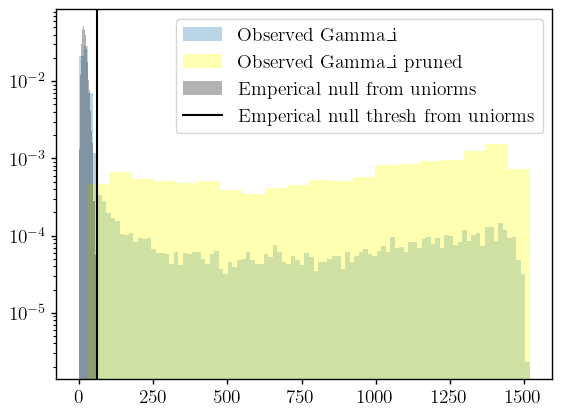

In [57]:
plist = stats_null_multi['p_list']
Gamma_null = np.sum(
    [
        stats_null_multi['by_ref'][ref_num]['stats_null'][p]
        for ref_num, p in enumerate(plist)
    ],
    axis=0
)


import numpy as np

def empirical_null_sum_gamma(stats_null_multi, plist, N_gamma=2_000_000, rng=None):
    """
    Empirical null for Gamma = sum_j Upsilon^(j), built by resampling from each ref's null.
    """
    if rng is None:
        rng = np.random.default_rng()

    # pull null arrays (1D) for each reference
    null_arrays = [
        np.asarray(stats_null_multi['by_ref'][j]['stats_null'][p], dtype=float)
        for j, p in enumerate(plist)
    ]

    Gamma_null = np.zeros(N_gamma, dtype=float)

    for arr in null_arrays:
        idx = rng.integers(0, arr.size, size=N_gamma)
        Gamma_null += arr[idx]

    return Gamma_null


import numpy as np

def p_to_upsilon(pvals, eps=1e-300):
    pvals = np.asarray(pvals, float)
    pvals = np.clip(pvals, eps, 1.0)
    return -np.log10(pvals)   # change if your Upsilon uses a different transform

def gamma_null_from_binomial_theory(stats_null_multi, plist, N_gamma=2_000_000, seed=0):
    rng = np.random.default_rng(seed)

    ups_null_arrays = []
    for j, p_j in enumerate(plist):
        null_p = np.asarray(stats_null_multi["by_ref"][j]["stats_null"][p_j], float)
        ups_null_arrays.append(null_p)

    Gamma_null = np.zeros(N_gamma, float)
    for ups in ups_null_arrays:
        idx = rng.integers(0, len(ups), size=N_gamma)
        Gamma_null += ups[idx]

    return Gamma_null


# Gamma_null = gamma_null_from_multi_refs_no_replacement(
#     stats_null_multi=stats_null_multi,
#     plist=plist,
#     N=50000,      # must be <= min len among refs' null arrays
#     which="plus",
#     seed=42
# )

# plt.yscale('log')
# --- 1) Combined null (Gamma_null) ---
# plt.hist(
#     Gamma_null,
#     bins=200,
#     density=True,
#     histtype='step',
#     linewidth=2,
#     label='Gamma null (sum)'
# )



# Gamma_null = empirical_null_sum_gamma(stats_null_multi, plist, N_gamma=2_000_000)
# # h=plt.hist(Gamma_i,bins=1000,density=True,alpha=0.3)
# plt.yscale('log')
# # --- 1) Combined null (Gamma_null) ---
# plt.hist(
#     Gamma_null,
#     bins=200,
#     density=True,
#     histtype='step',
#     linewidth=2,
#     label='Gamma null (empirical)'
# )




# Gamma_null_b_th = gamma_null_from_binomial_theory(stats_null_multi, plist, N_gamma=50000)
# # h=plt.hist(Gamma_i,bins=1000,density=True,alpha=0.3)
# plt.yscale('log')
# # --- 1) Combined null (Gamma_null) ---
# h = plt.hist(
#     Gamma_null_b_th,
#     bins=200,
#     density=True,
#     histtype='step',
#     linewidth=2,
#     label='Gamma null (From binomial th)'
# )


# # --- 2) Individual reference nulls ---
# for ref_num, p in enumerate(plist):
#     null_j = stats_null_multi['by_ref'][ref_num]['stats_null'][p]
#     plt.hist(
#         null_j,
#         bins=100,
#         density=True,
#         histtype='step',
#         alpha=0.4,
#         linewidth=1,
#         label=f'Null ref {ref_num}'
#     )

# --- 3) Observed Gamma_i ---
plt.hist(
    Gamma_i[np.isfinite(Gamma_i)],
    bins=100,
    density=True,
    alpha=0.3,
    label='Observed Gamma_i'
)


# # --- 3) Observed Gamma_i pruned ---
plt.hist(
    Gamma_i_pruned[idx_persist],
    bins=20,
    density=True,
    alpha=0.3,
    label='Observed Gamma_i pruned',color='yellow'
)




Gamma_null_1d = flatten_gamma_null(Gamma_null_mat)
alpha_pt = p_ext
Gamma_star_emp = np.quantile(Gamma_null_1d, 1 - alpha_pt)
print("Empirical Gamma*:", Gamma_star_emp)

# --- 3) Observed Gamma_i pruned ---
plt.hist(
    Gamma_null_1d,
    bins=100,
    density=True,
    alpha=0.3,
    label='Emperical null  from uniorms',color='k'
)


# plt.hist(
#     Gamma_null_1d_perm.ravel(),
#     bins=100,
#     density=True,
#     alpha=0.3,
#     label='Emperical null  perrms',
# )

# plt.hist(
#     M_perm.ravel(),
#     bins=100,
#     density=True,
#     alpha=0.3,
#     label='Emperical null  max perms ',
# )


# alpha_pt = 1e-4    # Bonferroni per-point level
# Gamma_star      = np.quantile(Gamma_null_b_th, 1 - alpha_pt)
# Gamma_star_emp =  np.quantile(Gamma_null, 1 - 1E-5)

gamma_sum_star = sum(upsilonsS)
# plt.axvline(x=Gamma_star,color='k',alpha=0.5)
# plt.axvline(Gamma_star,color='r')
plt.axvline(Gamma_star_emp,color='k',label='Emperical null thresh from uniorms')
# plt.axvline(Gamma_star_pointwise,color='r',label='Emperical null thresh from perms')

plt.legend()

plt.yscale('log')
# plt.xlim([0,200])

N persistent: 3186 out of 28846


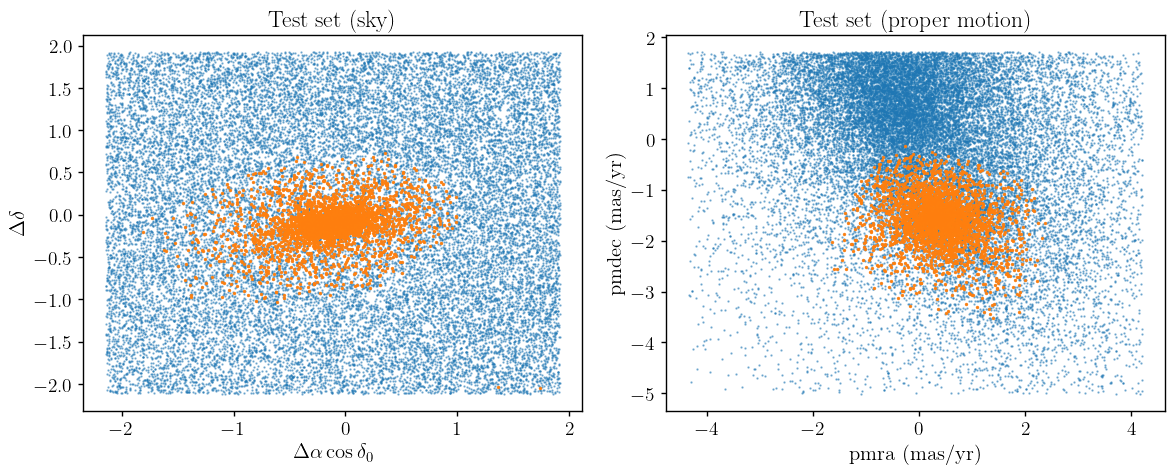

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --- build mask from persistence indices ---
mask_finite = np.isfinite(Gamma_i)

pass_thr = np.zeros(len(Y), dtype=bool)

# pass_thr[idx_persist] = True   # <-- use persistence indices
# pass_thr[Gamma_i<Gamma_star_emp] = False

pass_thr[Gamma_i>Gamma_star_emp] = True

print("N persistent:", sum(pass_thr), "out of", len(Y))

# --- features ---
x, y = Y[:, 0], Y[:, 1]      # sky-projected coords
u, v = Y[:, 2], Y[:, 3]      # pmra, pmdec

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =====================
# Panel A: sky
# =====================
axes[0].scatter(x[mask_finite], y[mask_finite],
                s=0.5, alpha=0.5, rasterized=True)

axes[0].scatter(x[pass_thr], y[pass_thr],
                s=2.0, alpha=0.9, rasterized=True)

axes[0].set_xlabel(r'$\Delta\alpha\cos\delta_0$')
axes[0].set_ylabel(r'$\Delta\delta$')
axes[0].set_title('Test set (sky)')

# =====================
# Panel B: proper motion
# =====================
axes[1].scatter(u[mask_finite], v[mask_finite],
                s=0.5, alpha=0.5, rasterized=True)

axes[1].scatter(u[pass_thr], v[pass_thr],
                s=2.0, alpha=0.9, rasterized=True)

axes[1].set_xlabel(r'pmra (mas/yr)')
axes[1].set_ylabel(r'pmdec (mas/yr)')
axes[1].set_title('Test set (proper motion)')

plt.tight_layout()
plt.show()

### Average Z-score

In [59]:
import numpy as np

def persist_significance_overlap_with_Gamma(
    EE_books,
    SrootB_by_ref,
    Gamma_pass_mask,
    overlap_min=1,
    use_cluster_key="Repechaged",
    verbose=True,
):

    A_Gamma_mask = np.asarray(Gamma_pass_mask, dtype=bool)
    nY = A_Gamma_mask.size
    A_Gamma_idx = np.where(A_Gamma_mask)[0]

    R = len(EE_books)

    Lambda_sum = np.zeros(nY, dtype=float)
    J_count    = np.zeros(nY, dtype=int)
    Y_persist_mask = np.zeros(nY, dtype=bool)

    support_by_ref = []

    for j in range(R):
        EE_book = EE_books[j]
        srb     = SrootB_by_ref[j]
        z_by_cluster = srb.get("s/root(B)", {})

        over_clusters = EE_book.get("Y_OVER_clusters", {})
        if not isinstance(over_clusters, dict) or len(over_clusters) == 0:
            support_by_ref.append({"ref": j, "supporting_clusters": []})
            continue

        supporting = []

        for cid in sorted(over_clusters.keys()):
            cdict = over_clusters[cid]

            if use_cluster_key == "Repechaged":
                members = np.asarray(cdict.get("Repechaged", []), dtype=int)
            elif use_cluster_key == "Repechaged+Pruned":
                members = np.unique(np.concatenate([
                    np.asarray(cdict.get("Repechaged", []), dtype=int),
                    np.asarray(cdict.get("Pruned", []), dtype=int),
                ]))
            else:
                raise ValueError("Unsupported cluster key option")

            if members.size == 0:
                continue

            overlap = np.intersect1d(members, A_Gamma_idx, assume_unique=False)
            overlap_size = overlap.size

            if overlap_size < overlap_min:
                continue

            overlap_fraction = overlap_size / members.size

            # get cluster z-score
            lam = z_by_cluster.get(cid, np.nan)
            try:
                lam = float(lam)
            except Exception:
                lam = np.nan

            # ---- NEW: ignore clusters with z <= 0 ----
            if not np.isfinite(lam) or lam <= 0:
                continue

            supporting.append({
                "cluster_id": cid,
                "Lambda": lam,
                "size_members": int(members.size),
                "size_overlap": int(overlap_size),
                "overlap_fraction": float(overlap_fraction),
            })

            # update persistent region
            Y_persist_mask[members] = True

            # update per-point Lambda
            Lambda_sum[members] += lam
            J_count[members]    += 1

        support_by_ref.append({"ref": j, "supporting_clusters": supporting})

        if verbose:
            if len(supporting) == 0:
                print(f"[ref {j}] no supporting clusters")
            else:
                print(f"[ref {j}] supporting clusters: {len(supporting)}")
                for s in supporting:
                    print(
                        f"  cid={s['cluster_id']}: "
                        f"|members|={s['size_members']}, "
                        f"|overlap|={s['size_overlap']}, "
                        f"overlap_frac={s['overlap_fraction']:.3f}, "
                        f"Lambda={s['Lambda']:.3f}"
                    )

    Lambda_bar = np.full(nY, np.nan)
    flagged = J_count > 0
    Lambda_bar[flagged] = Lambda_sum[flagged] / J_count[flagged]

    Y_persist_idx = np.where(Y_persist_mask)[0]

    persist_scored = Y_persist_mask & np.isfinite(Lambda_bar)
    if np.any(persist_scored):
        Lambda_persist = float(np.mean(Lambda_bar[persist_scored]))
    else:
        Lambda_persist = np.nan

    if verbose:
        print(f"\nA_Gamma size: {A_Gamma_idx.size}")
        print(f"Y_persist size: {Y_persist_idx.size}")
        print(f"Lambda^Persist: {Lambda_persist:.4f}\n")

    return {
        "A_Gamma_idx": A_Gamma_idx,
        "Y_persist_idx": Y_persist_idx,
        "Lambda_bar": Lambda_bar,
        "J_count": J_count,
        "Lambda_persist": Lambda_persist,
        "support_by_ref": support_by_ref,
    }
# -------------------------
# Example usage (exactly as you described)
# -------------------------
# final Gamma anomaly mask:
# pass_thr is boolean mask of Y already (e.g. finite + other criteria)
A_Gamma_mask = pass_thr 

out_persist = persist_significance_overlap_with_Gamma(
    EE_books=EE_books,
    SrootB_by_ref=SrootB_by_ref,
    Gamma_pass_mask=A_Gamma_mask,
    overlap_min=1,               # or 2/3 to avoid 1-point accidental overlaps
    use_cluster_key="Repechaged",
    verbose=True,
)

print("Lambda^Persist =", out_persist["Lambda_persist"])

[ref 0] supporting clusters: 1
  cid=1: |members|=2653, |overlap|=2620, overlap_frac=0.988, Lambda=174.799
[ref 1] supporting clusters: 1
  cid=0: |members|=2331, |overlap|=2331, overlap_frac=1.000, Lambda=159.314
[ref 2] supporting clusters: 1
  cid=0: |members|=2612, |overlap|=2612, overlap_frac=1.000, Lambda=111.333
[ref 3] supporting clusters: 1
  cid=1: |members|=2336, |overlap|=2336, overlap_frac=1.000, Lambda=153.188
[ref 4] supporting clusters: 1
  cid=1: |members|=2749, |overlap|=2747, overlap_frac=0.999, Lambda=76.772
[ref 5] supporting clusters: 1
  cid=1: |members|=2302, |overlap|=2302, overlap_frac=1.000, Lambda=126.654
[ref 6] supporting clusters: 1
  cid=0: |members|=2500, |overlap|=2500, overlap_frac=1.000, Lambda=89.870
[ref 7] supporting clusters: 1
  cid=0: |members|=3394, |overlap|=2995, overlap_frac=0.882, Lambda=32.694

A_Gamma size: 3186
Y_persist size: 3524
Lambda^Persist: 98.6892

Lambda^Persist = 98.68915304880812


In [60]:
import numpy as np
import pandas as pd

def standardize_overlay_df(df):
    """
    Return a copy with columns renamed to:
      ra_dr3, dec_dr3, pmra_dr3, pmdec_dr3
    Adjust the rename_map if your Battaglia table uses different names.
    """
    out = df.copy()

    rename_map = {}

    # RA
    for c in ["ra_dr3", "ra", "RA_ICRS", "_RA.icrs", "RAJ2000"]:
        if c in out.columns:
            rename_map[c] = "ra_dr3"
            break

    # Dec
    for c in ["dec_dr3", "dec", "DE_ICRS", "_DE.icrs", "DEJ2000"]:
        if c in out.columns:
            rename_map[c] = "dec_dr3"
            break

    # pmra
    for c in ["pmra_dr3", "pmra", "pmRA", "pmRA*", "pmRA_ICRS"]:
        if c in out.columns:
            rename_map[c] = "pmra_dr3"
            break

    # pmdec
    for c in ["pmdec_dr3", "pmdec", "pmDE", "pmDE_ICRS"]:
        if c in out.columns:
            rename_map[c] = "pmdec_dr3"
            break

    out = out.rename(columns=rename_map)

    need = ["ra_dr3", "dec_dr3"]
    missing = [c for c in need if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required sky columns: {missing}. Available: {list(out.columns)}")

    return out
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def get_Y_absolute_from_r(r, parts):
    test_idx = np.asarray(parts["test_idx"], dtype=int)

    raY    = np.asarray(r["ra"][test_idx], float)
    decY   = np.asarray(r["dec"][test_idx], float)
    pmraY  = np.asarray(r["pmra"][test_idx], float)
    pmdecY = np.asarray(r["pmdec"][test_idx], float)

    return raY, decY, pmraY, pmdecY


def plot_Gamma_clusters_abs_with_overlay(
    r,
    parts,
    gamma_clusters,
    cluster_stats,
    overlay_df,                 # generic overlay table
    overlay_label=r"Tucana II members",
    figsize=(8, 7),
    alpha_bg=0.25,
    s_bg=3,
    s_cl=25,
    s_overlay=65,
    title_sky=r"$\Gamma_\alpha$ clusters (sky)",
    title_pm=r"$\Gamma_\alpha$ clusters (proper motion)",
):
    raY, decY, pmraY, pmdecY = get_Y_absolute_from_r(r, parts)

    labels = sorted(gamma_clusters.keys())
    cmap = cm.get_cmap("tab10", max(1, len(labels)))

    # ------------------------
    # SKY
    # ------------------------
    plt.figure(figsize=figsize)

    plt.scatter(
        raY, decY,
        s=s_bg, alpha=alpha_bg, color="lightgray",
        rasterized=True, label=r"Test set $\mathcal{Y}$"
    )

    # overlay first
    plt.scatter(
        overlay_df["ra_dr3"].to_numpy(float),
        overlay_df["dec_dr3"].to_numpy(float),
        s=s_overlay, alpha=0.85,
        facecolors="none", edgecolors="red",
        linewidths=1.8,
        label=overlay_label
    )

    for k, gid in enumerate(labels):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if pts.size == 0:
            continue

        plt.scatter(
            raY[pts], decY[pts],
            s=s_cl, alpha=0.9, color=cmap(k),
            rasterized=True,
            label=rf"$\alpha={gid}$ (n={pts.size})"
        )

        cx = float(np.mean(raY[pts]))
        y_top = float(np.max(decY[pts]))
        y_range = float(np.nanmax(decY) - np.nanmin(decY))
        box_y = y_top + 0.03 * y_range

        srb = cluster_stats[int(gid)]["s_over_rootB"]
        S   = cluster_stats[int(gid)]["S"]
        B   = cluster_stats[int(gid)]["B_weighted"]

        txt = (
            rf"$\alpha={gid}$" + "\n" +
            rf"$S={S}$" + "\n" +
            rf"$\hat{{B}}={B:.1f}$" + "\n" +
            rf"$S/\sqrt{{\hat{{B}}}}={srb:.2f}$"
        )

        plt.text(
            cx, box_y, txt,
            fontsize=10, ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor="white", edgecolor="black", alpha=0.90)
        )

    plt.xlabel(r"RA $\mathrm{[deg]}$")
    plt.ylabel(r"DEC $\mathrm{[deg]}$")
    plt.title(title_sky)
    plt.gca().invert_xaxis()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend(frameon=True, fancybox=True, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    # ------------------------
    # PROPER MOTION
    # ------------------------
    if {"pmra_dr3", "pmdec_dr3"}.issubset(overlay_df.columns):
        plt.figure(figsize=figsize)

        plt.scatter(
            pmraY, pmdecY,
            s=s_bg, alpha=alpha_bg, color="lightgray",
            rasterized=True, label=r"Test set $\mathcal{Y}$"
        )

        plt.scatter(
            overlay_df["pmra_dr3"].to_numpy(float),
            overlay_df["pmdec_dr3"].to_numpy(float),
            s=s_overlay, alpha=0.85,
            facecolors="none", edgecolors="red",
            linewidths=1.8,
            label=overlay_label
        )

        for k, gid in enumerate(labels):
            pts = np.asarray(gamma_clusters[gid], dtype=int)
            if pts.size == 0:
                continue

            plt.scatter(
                pmraY[pts], pmdecY[pts],
                s=s_cl, alpha=0.9, color=cmap(k),
                rasterized=True,
                label=rf"$\alpha={gid}$ (n={pts.size})"
            )

            cx = float(np.mean(pmraY[pts]))
            y_top = float(np.max(pmdecY[pts]))
            y_range = float(np.nanmax(pmdecY) - np.nanmin(pmdecY))
            box_y = y_top + 0.03 * y_range

            srb = cluster_stats[int(gid)]["s_over_rootB"]
            S   = cluster_stats[int(gid)]["S"]
            B   = cluster_stats[int(gid)]["B_weighted"]

            txt = (
                rf"$\alpha={gid}$" + "\n" +
                rf"$S={S}$" + "\n" +
                rf"$\hat{{B}}={B:.1f}$" + "\n" +
                rf"$S/\sqrt{{\hat{{B}}}}={srb:.2f}$"
            )

            plt.text(
                cx, box_y, txt,
                fontsize=10, ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.35",
                          facecolor="white", edgecolor="black", alpha=0.90)
            )

        plt.xlabel(r"PMRA $\,\mathrm{[mas\,yr^{-1}]}$")
        plt.ylabel(r"PMDEC $\,\mathrm{[mas\,yr^{-1}]}$")
        plt.title(title_pm)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.legend(frameon=True, fancybox=True, framealpha=0.9, loc="lower left")
        plt.tight_layout()
        plt.show()

In [61]:
# GET TUCANA II STARS
import requests
from astropy.table import Table
from astroquery.vizier import Vizier
import io
import numpy as np
v = Vizier(columns=["**"], row_limit=-1)  # fetch all rows

catalog_id = "J/A+A/657/A54"

# List available tables in this catalog
catalogs = v.find_catalogs(catalog_id)
print(f"Battaglia+2022 catalog tables:")
result = v.get_catalogs(catalog_id)
for i, t in enumerate(result):
    print(f"  Table {i}: {t.meta.get('name','?')} — {len(t)} rows, cols: {t.colnames[:5]}...")

bata_tab = result[0]
galaxies = np.unique(bata_tab['Galaxy'])



boote_bat = bata_tab[(bata_tab['Galaxy']=='Carina') & (bata_tab['Pmemb']>0.5)]
tuc2_df = boote_bat.to_pandas()
tuc2_df = standardize_overlay_df(tuc2_df)

print(tuc2_df.head())
print(tuc2_df.columns)

Battaglia+2022 catalog tables:
  Table 0: J/A+A/657/A54/pmem — 645720 rows, cols: ['recno', 'Galaxy', 'GaiaEDR3', 'RA_ICRS', 'DE_ICRS']...
    recno  Galaxy             GaiaEDR3      ra_dr3    dec_dr3     Pmemb  \
0  421132  Carina  5501700209637479168   99.869435 -51.544162  0.954409   
1  421235  Carina  5501705187502887040  100.412476 -51.379545  0.525458   
2  421244  Carina  5501705397956987008  100.391196 -51.385820  0.577852   
3  421268  Carina  5501706497469283584  100.207126 -51.422705  0.729930   
4  421292  Carina  5501707562619243648  100.160317 -51.393926  0.658800   

     _RA.icrs   _DE.icrs  
0   99.869435 -51.544162  
1  100.412476 -51.379545  
2  100.391196 -51.385820  
3  100.207126 -51.422705  
4  100.160317 -51.393926  
Index(['recno', 'Galaxy', 'GaiaEDR3', 'ra_dr3', 'dec_dr3', 'Pmemb', '_RA.icrs',
       '_DE.icrs'],
      dtype='object')


In [62]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KDTree

# Battaglia member table -> pandas
tuc2_df = boote_bat.to_pandas().copy()

# rename sky columns if needed
rename_map = {}
for c in ["RAJ2000", "RA_ICRS", "_RA.icrs", "ra", "RAdeg"]:
    if c in tuc2_df.columns:
        rename_map[c] = "ra_deg"
        break
for c in ["DEJ2000", "DE_ICRS", "_DE.icrs", "dec", "DEdeg"]:
    if c in tuc2_df.columns:
        rename_map[c] = "dec_deg"
        break

tuc2_df = tuc2_df.rename(columns=rename_map)

if not {"ra_deg", "dec_deg"}.issubset(tuc2_df.columns):
    raise ValueError(f"Could not find RA/Dec columns. Columns are: {list(tuc2_df.columns)}")

# Gaia query table r
r_ra    = np.asarray(r["ra"], float)
r_dec   = np.asarray(r["dec"], float)
r_pmra  = np.asarray(r["pmra"], float)
r_pmdec = np.asarray(r["pmdec"], float)
r_sid   = np.asarray(r["source_id"])

# nearest-neighbour match in sky
tree = KDTree(np.column_stack([r_ra, r_dec]))

q_ra  = tuc2_df["ra_deg"].to_numpy(float)
q_dec = tuc2_df["dec_deg"].to_numpy(float)

dist, idx = tree.query(np.column_stack([q_ra, q_dec]), k=1)
dist = dist.ravel()
idx  = idx.ravel()

# tolerance in degrees: 1e-4 ~ 0.36 arcsec
tol = 1e-4
matched = dist < tol

print("Matched:", matched.sum(), "/", len(tuc2_df))
if matched.any():
    print("Worst matched sep (arcsec):", dist[matched].max() * 3600)

# attach Gaia DR3 astrometry/PM
tuc2_df["source_id_dr3"] = pd.NA
tuc2_df["ra_dr3"] = np.nan
tuc2_df["dec_dr3"] = np.nan
tuc2_df["pmra_dr3"] = np.nan
tuc2_df["pmdec_dr3"] = np.nan

tuc2_df.loc[matched, "source_id_dr3"] = r_sid[idx[matched]]
tuc2_df.loc[matched, "ra_dr3"] = r_ra[idx[matched]]
tuc2_df.loc[matched, "dec_dr3"] = r_dec[idx[matched]]
tuc2_df.loc[matched, "pmra_dr3"] = r_pmra[idx[matched]]
tuc2_df.loc[matched, "pmdec_dr3"] = r_pmdec[idx[matched]]

# keep only matched rows if you want PM plots
tuc2_matched = tuc2_df[matched].copy()

Matched: 2358 / 2358
Worst matched sep (arcsec): 0.0


In [63]:
import numpy as np
import pandas as pd

def standardize_overlay_df(df):
    """
    Return a copy with columns renamed to:
      ra_dr3, dec_dr3, pmra_dr3, pmdec_dr3
    Adjust the rename_map if your Battaglia table uses different names.
    """
    out = df.copy()

    rename_map = {}

    # RA
    for c in ["ra_dr3", "ra", "RA_ICRS", "_RA.icrs", "RAJ2000"]:
        if c in out.columns:
            rename_map[c] = "ra_dr3"
            break

    # Dec
    for c in ["dec_dr3", "dec", "DE_ICRS", "_DE.icrs", "DEJ2000"]:
        if c in out.columns:
            rename_map[c] = "dec_dr3"
            break

    # pmra
    for c in ["pmra_dr3", "pmra", "pmRA", "pmRA*", "pmRA_ICRS"]:
        if c in out.columns:
            rename_map[c] = "pmra_dr3"
            break

    # pmdec
    for c in ["pmdec_dr3", "pmdec", "pmDE", "pmDE_ICRS"]:
        if c in out.columns:
            rename_map[c] = "pmdec_dr3"
            break

    out = out.rename(columns=rename_map)

    need = ["ra_dr3", "dec_dr3"]
    missing = [c for c in need if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required sky columns: {missing}. Available: {list(out.columns)}")

    return out
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def get_Y_absolute_from_r(r, parts):
    test_idx = np.asarray(parts["test_idx"], dtype=int)

    raY    = np.asarray(r["ra"][test_idx], float)
    decY   = np.asarray(r["dec"][test_idx], float)
    pmraY  = np.asarray(r["pmra"][test_idx], float)
    pmdecY = np.asarray(r["pmdec"][test_idx], float)

    return raY, decY, pmraY, pmdecY

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def overlay_3x3_grid(center_ra, center_dec, cell_halfwidth_deg):
    """
    Draw dashed red lines showing the 3×3 grid boundaries.
    """

    h = float(cell_halfwidth_deg)

    # vertical boundaries (RA)
    for d in [-h, h]:
        plt.axvline(center_ra + d,
                    color="red",
                    linestyle="--",
                    linewidth=1.4,
                    alpha=0.9)

    # horizontal boundaries (Dec)
    for d in [-h, h]:
        plt.axhline(center_dec + d,
                    color="red",
                    linestyle="--",
                    linewidth=1.4,
                    alpha=0.9)

def plot_Gamma_clusters_abs_with_overlay(
    r,
    parts,
    gamma_clusters,         # dict: gid -> indices into Y (test-cell rows)
    cluster_stats,          # cluster_stats[gid]["s_over_rootB"], ["B_weighted"], ["S"]
    overlay_df,             # generic overlay table with ra_dr3/dec_dr3 and optional pmra_dr3/pmdec_dr3
    overlay_label=r"Tucana II members",
    figsize=(8, 7),
    alpha_bg=0.25,
    s_bg=3,
    s_cl=25,
    s_overlay=65,
    title_sky=r"$\Gamma_\alpha$ clusters (sky)",
    title_pm=r"$\Gamma_\alpha$ clusters (proper motion)",
    full_grid=False,        # <-- NEW
    show_grid_lines=True,   # <-- NEW, only relevant if full_grid=True
):
    """
    If full_grid=False:
        background = test cell only
        Gamma clusters plotted in absolute coords using test_idx mapping

    If full_grid=True:
        background = all points inside the 3x3 grid (test + 8 refs)
        Gamma clusters still plotted in the correct absolute coords of the test cell
    """
    # --- background set ---
    if full_grid:
        bg_idx = np.where(np.asarray(parts["inside"], bool))[0]
    else:
        bg_idx = np.asarray(parts["test_idx"], dtype=int)

    ra_bg    = np.asarray(r["ra"][bg_idx], float)
    dec_bg   = np.asarray(r["dec"][bg_idx], float)
    pmra_bg  = np.asarray(r["pmra"][bg_idx], float)
    pmdec_bg = np.asarray(r["pmdec"][bg_idx], float)

    # --- test-cell absolute coordinates aligned with Y rows ---
    test_idx = np.asarray(parts["test_idx"], dtype=int)
    raY    = np.asarray(r["ra"][test_idx], float)
    decY   = np.asarray(r["dec"][test_idx], float)
    pmraY  = np.asarray(r["pmra"][test_idx], float)
    pmdecY = np.asarray(r["pmdec"][test_idx], float)

    labels = sorted(gamma_clusters.keys())
    cmap = cm.get_cmap("tab10", max(1, len(labels)))

    # ========================
    # SKY
    # ========================
    plt.figure(figsize=figsize)

    plt.scatter(
        ra_bg, dec_bg,
        s=s_bg, alpha=alpha_bg, color="lightgray",
        rasterized=True,
    )

    # optional grid lines in absolute RA/Dec
    if full_grid and show_grid_lines:
        # infer center and halfwidth from parts if available
        # easiest from current test cell extent
        # but if you still have center_ra/center_dec/cell_halfwidth_deg in scope, use those directly
        pass


    if full_grid:
        overlay_3x3_grid(center_ra, center_dec, cell_halfwidth_deg)

    # Gamma clusters (always defined on test-cell Y)
    for k, gid in enumerate(labels):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if pts.size == 0:
            continue

        plt.scatter(
            raY[pts], decY[pts],
            s=s_cl, alpha=0.9, color=cmap(k),
            rasterized=True,
            label=rf"$\alpha={gid}$ (n={pts.size})"
        )

        cx = float(np.mean(raY[pts]))
        y_top = float(np.max(decY[pts]))
        y_range = float(np.nanmax(dec_bg) - np.nanmin(dec_bg))
        box_y = y_top + 0.03 * y_range

        srb = cluster_stats[int(gid)]["s_over_rootB"]
        S   = cluster_stats[int(gid)]["S"]
        B   = cluster_stats[int(gid)]["B_weighted"]

        txt = (
            rf"$\alpha={gid}$" + "\n" +
            rf"$S={S}$" + "\n" +
            rf"$\hat{{B}}={B:.1f}$" + "\n" +
            rf"$S/\sqrt{{\hat{{B}}}}={srb:.2f}$"
        )

        plt.text(
            cx, box_y, txt,
            fontsize=10, ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor="white", edgecolor="black", alpha=0.90)
        )
    # overlay known members
    plt.scatter(
        overlay_df["ra_dr3"].to_numpy(float),
        overlay_df["dec_dr3"].to_numpy(float),
        s=s_overlay, alpha=0.85,
        facecolors="none", edgecolors="red",
        linewidths=1.8,
        label=overlay_label
    )

    plt.xlabel(r"RA $\mathrm{[deg]}$")
    plt.ylabel(r"DEC $\mathrm{[deg]}$")
    plt.title(title_sky)
    plt.gca().invert_xaxis()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend(frameon=True, fancybox=True, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    # ========================
    # PM
    # ========================
    if {"pmra_dr3", "pmdec_dr3"}.issubset(overlay_df.columns):
        plt.figure(figsize=figsize)

        plt.scatter(
            pmra_bg, pmdec_bg,
            s=s_bg, alpha=alpha_bg, color="lightgray",
            rasterized=True,

        )


        for k, gid in enumerate(labels):
            pts = np.asarray(gamma_clusters[gid], dtype=int)
            if pts.size == 0:
                continue

            plt.scatter(
                pmraY[pts], pmdecY[pts],
                s=s_cl, alpha=0.9, color=cmap(k),
                rasterized=True,
                label=rf"$\alpha={gid}$ (n={pts.size})"
            )

            cx = float(np.mean(pmraY[pts]))
            y_top = float(np.max(pmdecY[pts]))
            y_range = float(np.nanmax(pmdec_bg) - np.nanmin(pmdec_bg))
            box_y = y_top + 0.03 * y_range

            srb = cluster_stats[int(gid)]["s_over_rootB"]
            S   = cluster_stats[int(gid)]["S"]
            B   = cluster_stats[int(gid)]["B_weighted"]

            txt = (
                rf"$\alpha={gid}$" + "\n" +
                rf"$S={S}$" + "\n" +
                rf"$\hat{{B}}={B:.1f}$" + "\n" +
                rf"$S/\sqrt{{\hat{{B}}}}={srb:.2f}$"
            )

            plt.text(
                cx, box_y, txt,
                fontsize=10, ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.35",
                          facecolor="white", edgecolor="black", alpha=0.90)
            )
        plt.scatter(
            overlay_df["pmra_dr3"].to_numpy(float),
            overlay_df["pmdec_dr3"].to_numpy(float),
            s=s_overlay, alpha=0.85,
            facecolors="none", edgecolors="red",
            linewidths=1.8,
            label=overlay_label
        )

        plt.xlabel(r"PMRA $\,\mathrm{[mas\,yr^{-1}]}$")
        plt.ylabel(r"PMDEC $\,\mathrm{[mas\,yr^{-1}]}$")
        plt.title(title_pm)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.legend(frameon=True, fancybox=True, framealpha=0.9, loc="lower left")
        plt.tight_layout()
        plt.show()

def srootB_for_Gamma_clusters_from_Brefs(
    EE_books,
    SrootB_by_ref,   # used only as filter: keep only EE clusters with z>0
    B_by_ref,        # your B_estimate_Y_overdensities outputs
    Y,
    A_Gamma_mask,
    overlap_min=1,
    use_cluster_key="Repechaged",
    weight_mode="overlap",      # "overlap" (default) or "n_support"
    dbscan_eps=0.6,
    dbscan_min_samples=5,
    cluster_cols=(0,1,2,3),
    verbose=True,
):
    """
    For each Gamma-cluster g (DBSCAN labels >= 0):
      S_g = |Gamma-cluster|
      B_g = weighted avg of Bhat(c,j) over (ref j, EE cluster c) with:
            - EE cluster intersects Gamma cluster (>= overlap_min points)
            - EE cluster z-score > 0
      s/sqrt(B)_g = (S_g - B_g)/sqrt(B_g)

    Returns dict with clusters, noise_idx, and per-cluster stats.
    """

    A_Gamma_mask = np.asarray(A_Gamma_mask, bool)
    nY = Y.shape[0]
    if A_Gamma_mask.size != nY:
        raise ValueError("A_Gamma_mask must have length len(Y)")

    labels_all, gamma_clusters, noise_idx = cluster_A_Gamma_DBSCAN_no_noise(
        Y, A_Gamma_mask, eps=dbscan_eps, min_samples=dbscan_min_samples, use_cols=cluster_cols
    )

    R = len(EE_books)
    if len(SrootB_by_ref) != R or len(B_by_ref) != R:
        raise ValueError("EE_books, SrootB_by_ref, B_by_ref must have same length")

    def _EE_members(cdict):
        if use_cluster_key == "Repechaged":
            return np.asarray(cdict.get("Repechaged", []), dtype=int)
        elif use_cluster_key == "Repechaged+Pruned":
            return np.unique(np.concatenate([
                np.asarray(cdict.get("Repechaged", []), dtype=int),
                np.asarray(cdict.get("Pruned", []), dtype=int),
            ]))
        else:
            raise ValueError("use_cluster_key must be 'Repechaged' or 'Repechaged+Pruned'")

    cluster_stats = {}

    if verbose:
        print(f"\nA_Gamma total size: {A_Gamma_mask.sum()}")
        print(f"DBSCAN clusters (>=0): {sorted(gamma_clusters.keys())}")
        print(f"DBSCAN noise points (ignored): {noise_idx.size}\n")

    for gid, A_idx in gamma_clusters.items():
        A_idx = np.asarray(A_idx, dtype=int)
        S = int(A_idx.size)

        B_num = 0.0
        W_num = 0.0
        contributors = []  # store (ref, cid, overlap, w, Bhat, z)

        for j in range(R):
            EE_book = EE_books[j]
            srb     = SrootB_by_ref[j]
            bhat    = B_by_ref[j]

            z_by_cluster = srb.get("s/root(B)", {})
            B_by_cluster = bhat.get("B", {})

            over_clusters = EE_book.get("Y_OVER_clusters", {})
            if not isinstance(over_clusters, dict) or len(over_clusters) == 0:
                continue

            for cid in sorted(over_clusters.keys()):
                members = _EE_members(over_clusters[cid])
                if members.size == 0:
                    continue

                ov = int(np.intersect1d(members, A_idx, assume_unique=False).size)
                if ov < int(overlap_min):
                    continue

                # filter: use only EE clusters with z>0
                z = z_by_cluster.get(cid, np.nan)
                try:
                    z = float(z)
                except Exception:
                    z = np.nan
                if not np.isfinite(z) or z <= 0:
                    continue

                Bc = B_by_cluster.get(cid, np.nan)
                try:
                    Bc = float(Bc)
                except Exception:
                    Bc = np.nan
                if not np.isfinite(Bc) or Bc <= 0:
                    continue

                if weight_mode == "overlap":
                    w = float(ov)
                elif weight_mode == "n_support":
                    w = 1.0
                else: 
                    raise ValueError("weight_mode must be 'overlap' or 'n_support'")

                B_num += w * Bc
                W_num += w
                contributors.append({"ref": j, "cid": int(cid), "overlap": ov, "w": w, "Bhat": Bc, "z": z})

        B_weighted = (B_num / W_num) if W_num > 0 else np.nan
        s_over_rootB = (S) / np.sqrt(B_weighted) if np.isfinite(B_weighted) and B_weighted > 0 else np.nan

        cluster_stats[int(gid)] = {
            "S": S,
            "B_weighted": B_weighted,
            "s_over_rootB": s_over_rootB,
            "contributors": contributors,
            "W_num": W_num,
            "A_idx": A_idx,
        }

        if verbose:
            print(f"[Gamma cluster {gid}] S={S:4d}  B̂={B_weighted}  s/√B={s_over_rootB}")

    return {
        "gamma_clusters": gamma_clusters,
        "noise_idx": noise_idx,
        "cluster_stats": cluster_stats,
        "labels_all": labels_all,
        "dbscan": {"eps": dbscan_eps, "min_samples": dbscan_min_samples, "cols": cluster_cols},
        "use_cluster_key": use_cluster_key,
        "weight_mode": weight_mode,
        "overlap_min": overlap_min,
    }

from sklearn.cluster import DBSCAN
def cluster_A_Gamma_DBSCAN_no_noise(
    Y, A_Gamma_mask, eps=0.6, min_samples=5, use_cols=(0,1,2,3)
):
    """
    Cluster A_Gamma points using DBSCAN and DROP noise (-1).
    Returns:
      labels_all : (nY,) int, -2 outside A_Gamma, -1 for A_Gamma noise, >=0 cluster labels
      clusters   : dict {label>=0 : np.ndarray(indices)}
      noise_idx  : np.ndarray(indices)  (A_Gamma points labeled -1)
    """
    A_Gamma_mask = np.asarray(A_Gamma_mask, bool)
    nY = Y.shape[0]
    idx = np.where(A_Gamma_mask)[0]

    labels_all = np.full(nY, -2, dtype=int)  # -2 = not in A_Gamma
    if idx.size == 0:
        return labels_all, {}, np.array([], dtype=int)

    Z = np.asarray(Y[:, use_cols], float)
    lab = DBSCAN(eps=float(eps), min_samples=int(min_samples)).fit_predict(Z[idx])

    labels_all[idx] = lab
    noise_idx = idx[lab == -1]

    clusters = {}
    for k in np.unique(lab):
        if k == -1:
            continue
        clusters[int(k)] = idx[lab == k]

    return labels_all, clusters, noise_idx



A_Gamma total size: 3186
DBSCAN clusters (>=0): [0]
DBSCAN noise points (ignored): 2

[Gamma cluster 0] S=3184  B̂=589.6869984139164  s/√B=131.1179899517942


/tmp/ipykernel_3956950/3776927452.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", max(1, len(labels)))
/tmp/ipykernel_3956950/3776927452.py:207: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/scratch/ascaffid/anaconda3/envs/lhc/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/scratch/ascaffid/anaconda3/envs/lhc/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


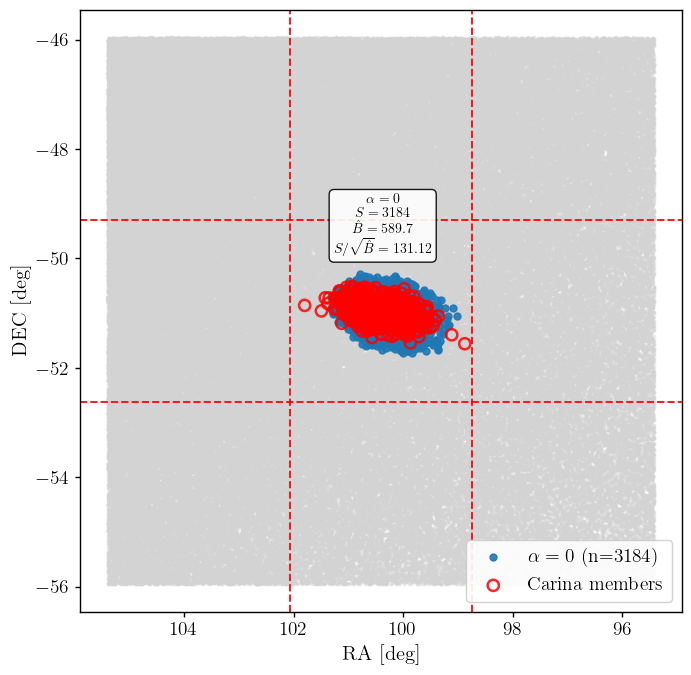

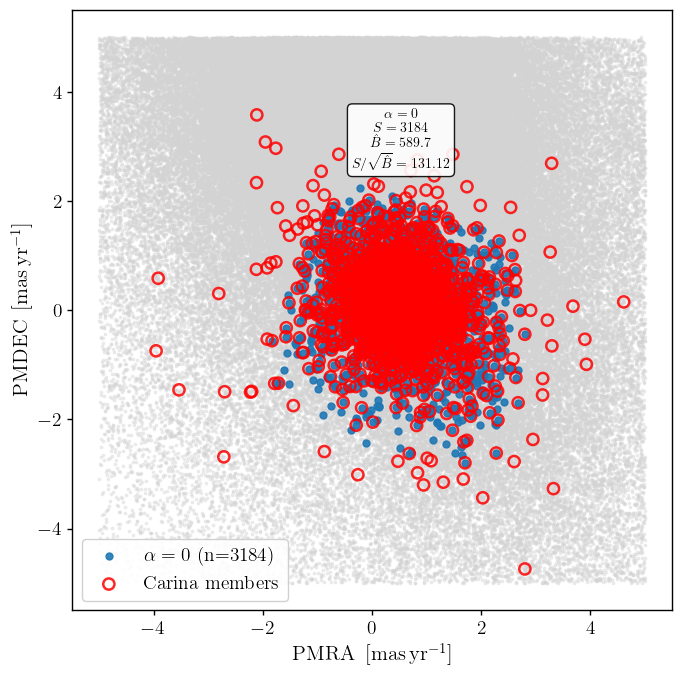

In [64]:
def set_pub_style(use_tex=False, fontsize=12):
    """
    If you have a TeX install, set use_tex=True for full LaTeX rendering.
    Otherwise this uses Matplotlib mathtext (still looks good).
    """
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 2,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "text.usetex": bool(use_tex),   # set True only if TeX is installed
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
    })

set_pub_style(use_tex=True, fontsize=15)

A_Gamma_mask = pass_thr & (Gamma_i > Gamma_star_emp)

out = srootB_for_Gamma_clusters_from_Brefs(
    EE_books=EE_books,
    SrootB_by_ref=SrootB_by_ref,
    B_by_ref=B_by_ref,
    Y=Y,
    A_Gamma_mask=A_Gamma_mask,
    overlap_min=1,
    use_cluster_key="Repechaged",
    weight_mode="overlap",
    dbscan_eps=1,
    dbscan_min_samples=5,
    cluster_cols=(0,1,2,3),
    verbose=True,
)

plot_Gamma_clusters_abs_with_overlay(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    cluster_stats=out["cluster_stats"],
    overlay_df=tuc2_df,
    overlay_label=r"Carina members",
    alpha_bg=0.35,
    title_sky=r"",
    title_pm=r"",
    full_grid=True,
)

## Plots

Overlay points matched by Gamma clusters in position space: 2272/2358
TPR: 0.964


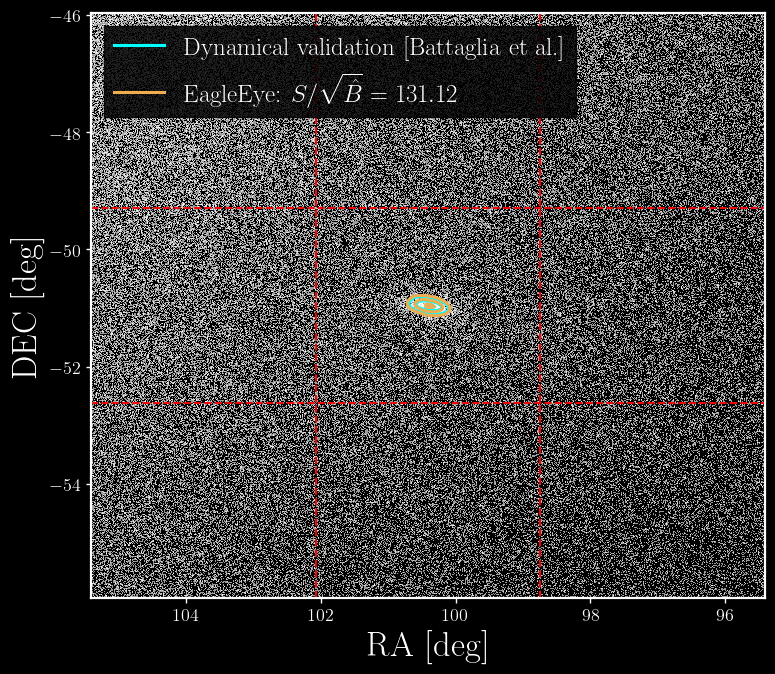

Overlay points matched by Gamma clusters in PM space: 2282/2358
TPR: 0.968


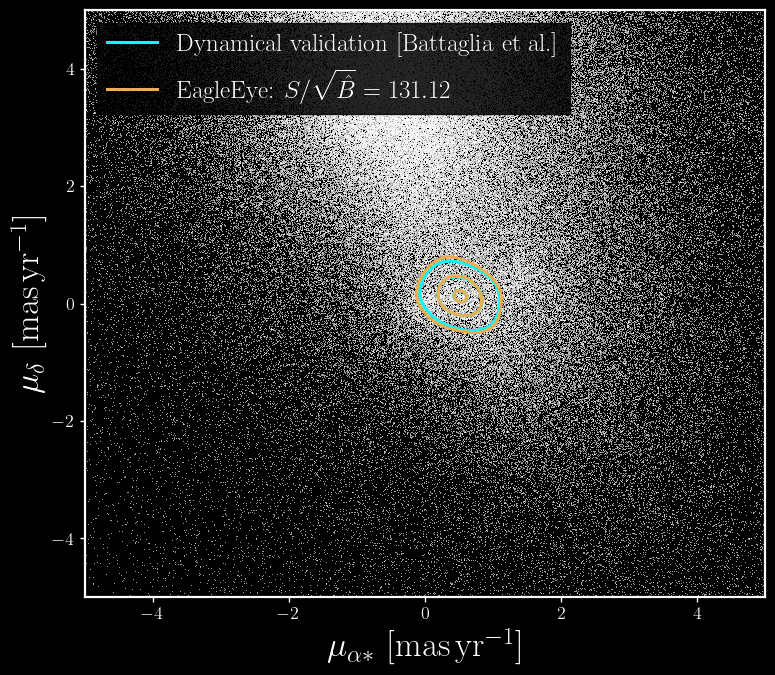

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
from sklearn.neighbors import KDTree

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import gaussian_kde


import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import gaussian_kde


import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import gaussian_kde


def plot_Gamma_clusters_abs_with_kde_overlay_pm(
    r,
    parts,
    gamma_clusters,          # dict: gid -> indices into Y
    overlay_df=None,         # DataFrame with PM or sky-position columns
    overlay_label=r"Dynamical validation [Battaglia et al.]",
    cluster_stats=None,      # e.g. out["cluster_stats"]

    # mode switch
    plot_space="pm",         # "pm" or "pos"

    # PM-space guide box
    center_pmra=None,
    center_pmdec=None,
    dpm=None,

    # sky-position guide box
    center_ra=None,
    center_dec=None,
    degsep=None,

    figsize=(8, 7),
    s_bg=2,
    alpha_bg=0.35,

    # Gamma display options
    gamma_as_points=True,
    gamma_as_kde=False,
    s_gamma=22,
    alpha_gamma=0.9,
    gamma_kde_levels=(0.5, 0.8),
    gamma_min_pts_kde=5,

    # Overlay display options
    overlay_as_points=True,
    overlay_as_kde=False,
    s_overlay=60,
    alpha_overlay=0.95,
    overlay_kde_levels=(0.5, 0.8),
    overlay_min_pts_kde=5,

    # Shared KDE settings
    kde_grid=200,

    # Column names: PM
    r_pmra_col="pmra",
    r_pmdec_col="pmdec",
    overlay_pmra_col="pmra_dr3",
    overlay_pmdec_col="pmdec_dr3",

    # Column names: sky position
    r_ra_col="ra",
    r_dec_col="dec",
    overlay_ra_col="ra_dr3",
    overlay_dec_col="dec_dr3",

    title=r"",
    print_overlap=True,
    overlap_tol=None,        # default chosen from plot_space if None
    invert_x=None,           # default chosen from plot_space if None
):
    """
    Exact-style replica of the PM-space plot, with the option to plot either in:
      - proper-motion space: plot_space="pm"
      - sky-position space:  plot_space="pos"

    Plot:
      - full original query box as background points
      - Gamma clusters optionally as points and/or KDE
      - overlay points optionally as points and/or KDE

    Notes
    -----
    gamma_clusters indices are assumed to index rows of Y, i.e. the test set.
    We use parts["test_idx"] to map those back to rows in r and then to absolute coordinates
    in either PM space or sky-position space.
    """

    def _gamma_label(gid, npts):
        if cluster_stats is None:
            return rf"EagleEye: $\Gamma_{{{gid}}}$"
        srb = cluster_stats[int(gid)]["s_over_rootB"]
        return rf"EagleEye: $S/\sqrt{{\hat{{B}}}}={srb:.2f}$"

    if plot_space not in {"pm", "pos"}:
        raise ValueError("plot_space must be either 'pm' or 'pos'")

    # defaults depending on space
    if overlap_tol is None:
        overlap_tol = 0.05 if plot_space == "pm" else 1e-4

    if invert_x is None:
        invert_x = False if plot_space == "pm" else True

    # choose coordinate columns and labels
    if plot_space == "pm":
        x_all = np.asarray(r[r_pmra_col], float)
        y_all = np.asarray(r[r_pmdec_col], float)

        test_idx = np.asarray(parts["test_idx"], dtype=int)
        xY = np.asarray(r[r_pmra_col][test_idx], float)
        yY = np.asarray(r[r_pmdec_col][test_idx], float)

        if overlay_df is not None and len(overlay_df) > 0:
            x_mem = overlay_df[overlay_pmra_col].to_numpy(float)
            y_mem = overlay_df[overlay_pmdec_col].to_numpy(float)
            finite_mem = np.isfinite(x_mem) & np.isfinite(y_mem)
            x_mem = x_mem[finite_mem]
            y_mem = y_mem[finite_mem]
        else:
            x_mem, y_mem = None, None

        xlabel = r"$\mu_{\alpha *}\ \mathrm{[mas\,yr^{-1}]}$"
        ylabel = r"$\mu_{\delta}\ \mathrm{[mas\,yr^{-1}]}$"
        overlap_msg = "Overlay points matched by Gamma clusters in PM space"

    else:  # plot_space == "pos"
        x_all = np.asarray(r[r_ra_col], float)
        y_all = np.asarray(r[r_dec_col], float)

        test_idx = np.asarray(parts["test_idx"], dtype=int)
        xY = np.asarray(r[r_ra_col][test_idx], float)
        yY = np.asarray(r[r_dec_col][test_idx], float)

        if overlay_df is not None and len(overlay_df) > 0:
            x_mem = overlay_df[overlay_ra_col].to_numpy(float)
            y_mem = overlay_df[overlay_dec_col].to_numpy(float)
            finite_mem = np.isfinite(x_mem) & np.isfinite(y_mem)
            x_mem = x_mem[finite_mem]
            y_mem = y_mem[finite_mem]
        else:
            x_mem, y_mem = None, None

        xlabel = r"RA $\mathrm{[deg]}$"
        ylabel = r"DEC $\mathrm{[deg]}$"
        overlap_msg = "Overlay points matched by Gamma clusters in position space"

    # finite mask for all background points
    finite_all = np.isfinite(x_all) & np.isfinite(y_all)
    x_all = x_all[finite_all]
    y_all = y_all[finite_all]

    # plotting window / KDE grid
    xmin, xmax = np.nanmin(x_all), np.nanmax(x_all)
    ymin, ymax = np.nanmin(y_all), np.nanmax(y_all)

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, kde_grid),
        np.linspace(ymin, ymax, kde_grid)
    )
    grid = np.vstack([xx.ravel(), yy.ravel()])

    # figure styling
    fig, ax = plt.subplots(figsize=figsize, facecolor="black")
    ax.set_facecolor("black")

    # full field
    ax.scatter(
        x_all, y_all,
        s=s_bg, c="white", alpha=alpha_bg,
        rasterized=True, linewidths=0
    )
    ax.margins(x=0, y=0)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # optional guide box / cross lines
    if plot_space == "pm":
        if center_pmra is not None and center_pmdec is not None and dpm is not None:
            ax.axvline(center_pmra - dpm/3, color="red", ls="--", lw=1.4, alpha=0.95)
            ax.axvline(center_pmra + dpm/3, color="red", ls="--", lw=1.4, alpha=0.95)
            ax.axhline(center_pmdec - dpm/3, color="red", ls="--", lw=1.4, alpha=0.95)
            ax.axhline(center_pmdec + dpm/3, color="red", ls="--", lw=1.4, alpha=0.95)
    else:
        if center_ra is not None and center_dec is not None and degsep is not None:
            ax.axvline(center_ra - degsep/3, color="red", ls="--", lw=1.4, alpha=0.95)
            ax.axvline(center_ra + degsep/3, color="red", ls="--", lw=1.4, alpha=0.95)
            ax.axhline(center_dec - degsep/3, color="red", ls="--", lw=1.4, alpha=0.95)
            ax.axhline(center_dec + degsep/3, color="red", ls="--", lw=1.4, alpha=0.95)

    labels = sorted(gamma_clusters.keys())
    gamma_color = "#f0ad4e"
    overlay_color = "cyan"

    gamma_union = []
# Overlay
    if x_mem is not None:
        if overlay_as_points:
            ax.scatter(
                x_mem, y_mem,
                s=s_overlay,
                facecolors="none",
                edgecolors=overlay_color,
                linewidths=1.8,
                alpha=alpha_overlay,
            )

        if overlay_as_kde and len(x_mem) >= overlay_min_pts_kde:
            vals = np.vstack([x_mem, y_mem])
            kde = gaussian_kde(vals)
            zz = kde(grid).reshape(xx.shape)

            zmax = np.nanmax(zz)
            levels = [lev * zmax for lev in overlay_kde_levels]

            ax.contour(
                xx, yy, zz,
                levels=levels,
                colors=[overlay_color] * len(levels),
                linewidths=2.2,
                alpha=0.98
            )
            ax.plot([], [], color=overlay_color, lw=2.2, label=overlay_label)
    # Gamma clusters
    for k, gid in enumerate(labels):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if pts.size == 0:
            continue

        x_c = xY[pts]
        y_c = yY[pts]
        finite_c = np.isfinite(x_c) & np.isfinite(y_c)
        x_c = x_c[finite_c]
        y_c = y_c[finite_c]

        if len(x_c) == 0:
            continue

        gamma_union.append(np.column_stack([x_c, y_c]))
        base_label = _gamma_label(gid, len(x_c))

        if gamma_as_points:
            ax.scatter(
                x_c, y_c,
                s=s_gamma,
                alpha=alpha_gamma,
                color=gamma_color,
                linewidths=1,marker="o",facecolors='none',edgecolors=gamma_color,
            )

        if gamma_as_kde and len(x_c) >= gamma_min_pts_kde:
            vals = np.vstack([x_c, y_c])
            kde = gaussian_kde(vals)
            zz = kde(grid).reshape(xx.shape)

            zmax = np.nanmax(zz)
            levels = [lev * zmax for lev in gamma_kde_levels]

            ax.contour(
                xx, yy, zz,
                levels=levels,
                colors=[gamma_color] * len(levels),
                linewidths=2.2,
                alpha=0.98
            )
            ax.plot([], [], color=gamma_color, lw=2.2, label=base_label)

    

    # optional overlap / TPR summary
    if print_overlap and x_mem is not None and gamma_union:
        gamma_union = np.vstack(gamma_union)
        overlay_pts = np.column_stack([x_mem, y_mem])

        matched = 0
        for p in overlay_pts:
            d2 = (gamma_union[:, 0] - p[0])**2 + (gamma_union[:, 1] - p[1])**2
            if np.any(d2 <= overlap_tol**2):
                matched += 1

        tpr = matched / len(overlay_pts) if len(overlay_pts) else np.nan
        print(f"{overlap_msg}: {matched}/{len(overlay_pts)}")
        print(f"TPR: {tpr:.3f}")

    # styling
    ax.set_xlabel(xlabel, color="white", fontsize=25)
    ax.set_ylabel(ylabel, color="white", fontsize=25)
    ax.set_title(title, color="white", fontsize=25)

    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_linewidth(1.6)

    ax.tick_params(colors="white", labelsize=13)

    if invert_x:
        ax.invert_xaxis()
    if gamma_as_kde or overlay_as_kde:
        leg = ax.legend(
            frameon=True, fancybox=False, framealpha=0.85,
            loc="upper left", fontsize=18
        )
        leg.get_frame().set_facecolor("black")
        leg.get_frame().set_edgecolor(None)
        for txt in leg.get_texts():
            txt.set_color("white")

    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def gamma_cluster_overlap_by_source_id(r, parts, gamma_clusters, overlay_df,
                                       overlay_id_col="source_id_dr3"):
    """
    Exact overlap between Gamma clusters and known members using Gaia source IDs.

    Parameters
    ----------
    r : astropy Table or pandas-like
        Gaia query table used to build Y/X_refs. Must contain 'source_id'.
    parts : dict
        Output of make_Xrefs_and_Y_from_window_3x3(...), must contain 'test_idx'.
    gamma_clusters : dict
        Dict {gid: np.ndarray of indices into Y}
    overlay_df : pandas.DataFrame
        Known-member table containing overlay_id_col
    overlay_id_col : str
        Column in overlay_df with DR3 source IDs

    Returns
    -------
    out : dict
        Contains total overlap and per-cluster overlap statistics.
    """
    test_idx = np.asarray(parts["test_idx"], dtype=int)
    y_source_ids = np.asarray(r["source_id"][test_idx])

    member_ids = pd.Series(overlay_df[overlay_id_col]).dropna().astype("int64").to_numpy()
    member_id_set = set(member_ids.tolist())

    cluster_results = {}
    union_ids = set()

    for gid, pts in gamma_clusters.items():
        pts = np.asarray(pts, dtype=int)
        if pts.size == 0:
            cluster_results[int(gid)] = {
                "n_cluster": 0,
                "n_overlap": 0,
                "tpr_members": 0.0,
                "matched_source_ids": np.array([], dtype=np.int64),
            }
            continue

        cluster_ids = y_source_ids[pts].astype("int64")
        cluster_id_set = set(cluster_ids.tolist())
        matched_ids = np.array(sorted(cluster_id_set & member_id_set), dtype=np.int64)

        union_ids.update(cluster_id_set)

        cluster_results[int(gid)] = {
            "n_cluster": int(len(cluster_ids)),
            "n_overlap": int(len(matched_ids)),
            "tpr_members": float(len(matched_ids) / len(member_ids)) if len(member_ids) > 0 else np.nan,
            "matched_source_ids": matched_ids,
        }

    union_matched = np.array(sorted(union_ids & member_id_set), dtype=np.int64)

    out = {
        "n_members_total": int(len(member_ids)),
        "n_overlap_total": int(len(union_matched)),
        "TPR_total": float(len(union_matched) / len(member_ids)) if len(member_ids) > 0 else np.nan,
        "matched_source_ids_total": union_matched,
        "cluster_results": cluster_results,
    }
    return out



res_overlap = plot_Gamma_clusters_abs_with_kde_overlay_pm(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    overlay_df=tuc2_df,   # must contain ra_dr3, dec_dr3
    overlay_label=r"Dynamical validation [Battaglia et al.]",
    center_ra=center_ra,
    plot_space="pos",
    center_dec=center_dec,
    degsep=degsep,
    figsize=(8, 7),
    s_bg=0.5,
    alpha_bg=0.5,
    cluster_stats=out["cluster_stats"],
    # s_overlay=10,
        # Gamma display options
    gamma_as_points=False,
    gamma_as_kde=True,
    s_gamma=20,
    alpha_gamma=0.8,
    gamma_kde_levels=(0.3, 0.6, 0.95),
    gamma_min_pts_kde=5,

    # Overlay display options
    overlay_as_points=False,
    overlay_as_kde=True,
    s_overlay=6,
    alpha_overlay=1,
    overlay_kde_levels=(0.3, 0.6, 0.95),

    # Shared KDE settings
    kde_grid=250,
    title=r"",
    print_overlap=True,
)
plot_Gamma_clusters_abs_with_kde_overlay_pm(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    overlay_df=tuc2_df,
    cluster_stats=out["cluster_stats"],
    plot_space="pm",
    r_pmra_col="pmra",
    r_pmdec_col="pmdec",
    overlay_pmra_col="pmra_dr3",
    overlay_pmdec_col="pmdec_dr3",
    center_pmra=None,   # set if you want cyan guide lines
    center_pmdec=None,
    dpm=None,
    invert_x=False,

        figsize=(8, 7),
    s_bg=0.5,
    alpha_bg=0.5,
    # s_overlay=10,
        # Gamma display options
    gamma_as_points=False,
    gamma_as_kde=True,
    s_gamma=20,
    alpha_gamma=0.8,
    gamma_kde_levels=(0.3, 0.6, 0.95),

    # Overlay display options
    overlay_as_points=False,
    overlay_as_kde=True,
    s_overlay=6,
    alpha_overlay=1,
    overlay_kde_levels=(0.3, 0.6, 0.95),

    # Shared KDE settings
    kde_grid=250,
    title=r"",
    print_overlap=True,
)

In [103]:
overlap_out = gamma_cluster_overlap_by_source_id(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    overlay_df=tuc2_df,
    overlay_id_col="source_id_dr3",
)

print("Total overlap:", overlap_out["n_overlap_total"], "/", overlap_out["n_members_total"])
print("Total TPR:", overlap_out["TPR_total"])

for gid, res in overlap_out["cluster_results"].items():
    print(
        f"Gamma cluster {gid}: "
        f"n_cluster={res['n_cluster']}, "
        f"n_overlap={res['n_overlap']}, "
        f"TPR={res['tpr_members']:.3f}"
    )

Total overlap: 2272 / 2358
Total TPR: 0.9635284139100933
Gamma cluster 0: n_cluster=3184, n_overlap=2272, TPR=0.964


In [106]:
import numpy as np
import pandas as pd


def angular_sep_deg(ra1_deg, dec1_deg, ra2_deg, dec2_deg):
    """
    Great-circle separation in degrees.
    """
    ra1 = np.deg2rad(ra1_deg)
    dec1 = np.deg2rad(dec1_deg)
    ra2 = np.deg2rad(ra2_deg)
    dec2 = np.deg2rad(dec2_deg)

    cosang = (
        np.sin(dec1) * np.sin(dec2)
        + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2)
    )
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.rad2deg(np.arccos(cosang))


def small_field_centroid(ra_deg, dec_deg):
    """
    Mean centroid for small sky patches.
    Uses cos(dec)-weighted RA average.
    """
    ra_deg = np.asarray(ra_deg, float)
    dec_deg = np.asarray(dec_deg, float)

    if len(ra_deg) == 0:
        return np.nan, np.nan

    dec0 = np.deg2rad(np.nanmean(dec_deg))
    w = np.cos(dec0)
    ra_c = np.nanmean(ra_deg * w) / w if w != 0 else np.nanmean(ra_deg)
    dec_c = np.nanmean(dec_deg)
    return ra_c, dec_c


def compute_gamma_cluster_report(
    r,
    parts,
    gamma_clusters,
    cluster_stats,
    overlay_df,
    overlap_out=None,              # <-- now explicitly the output of gamma_cluster_overlap_by_source_id
    overlay_source_id_col="source_id_dr3",
    overlay_ra_col="ra_dr3",
    overlay_dec_col="dec_dr3",
):
    """
    Compute per-Gamma-cluster reporting quantities.

    Expected overlap_out format:
        overlap_out = gamma_cluster_overlap_by_source_id(...)
        overlap_out["cluster_results"][gid] = {
            "n_cluster": ...,
            "n_overlap": ...,
            "tpr_members": ...,
            ...
        }

    If overlap_out["cluster_results"][gid] also contains matched source IDs under one of:
        - 'matched_source_ids'
        - 'overlap_source_ids'
        - 'member_source_ids'
        - 'source_ids'
    then centroid validation against matched overlay points is computed.
    Otherwise matched overlay centroid fields will be NaN.
    """

    # Map Y indices back to absolute coordinates
    test_idx = np.asarray(parts["test_idx"], dtype=int)
    raY = np.asarray(r["ra"][test_idx], float)
    decY = np.asarray(r["dec"][test_idx], float)

    # Overlay lookup by source id
    overlay_lookup = {}
    if overlay_df is not None and len(overlay_df) > 0:
        for _, row in overlay_df.iterrows():
            sid = row[overlay_source_id_col]
            overlay_lookup[sid] = (
                float(row[overlay_ra_col]),
                float(row[overlay_dec_col]),
            )

    rows = []

    for gid in sorted(gamma_clusters.keys()):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if len(pts) == 0:
            continue

        # Gamma-cluster coordinates
        ra_c = raY[pts]
        dec_c = decY[pts]

        # Cluster centroid
        gamma_ra_cent, gamma_dec_cent = small_field_centroid(ra_c, dec_c)

        # Stats from cluster_stats
        cs = cluster_stats[int(gid)]
        srb = float(cs["s_over_rootB"])
        S = float(cs["S"])
        B = float(cs["B_weighted"])
        n_gamma = int(len(pts))

        # Overlap info from gamma_cluster_overlap_by_source_id output
        n_matched = np.nan
        tpr = np.nan
        matched_ids = []

        if overlap_out is not None:
            cres = overlap_out.get("cluster_results", {}).get(gid, None)
            if cres is None:
                cres = overlap_out.get("cluster_results", {}).get(str(gid), None)

            if cres is not None:
                n_matched = int(cres.get("n_overlap", 0))
                tpr = float(cres.get("tpr_members", np.nan))

                # optional matched IDs if present
                for key in [
                    "matched_source_ids",
                    "overlap_source_ids",
                    "member_source_ids",
                    "source_ids",
                ]:
                    if key in cres:
                        matched_ids = list(cres[key])
                        break

                # trust overlap function's n_cluster if you want, but keep ours from gamma_clusters
                # n_gamma = int(cres.get("n_cluster", n_gamma))

        if np.isnan(n_matched):
            n_matched = 0

        n_extra = n_gamma - n_matched
        impurity = n_extra / n_gamma if n_gamma > 0 else np.nan

        # Matched overlay centroid, only if matched source IDs are available
        matched_overlay_coords = [
            overlay_lookup[sid]
            for sid in matched_ids
            if sid in overlay_lookup
        ]

        if len(matched_overlay_coords) > 0:
            ra_match = np.array([x[0] for x in matched_overlay_coords], float)
            dec_match = np.array([x[1] for x in matched_overlay_coords], float)

            ov_ra_cent, ov_dec_cent = small_field_centroid(ra_match, dec_match)
            centroid_sep_deg = angular_sep_deg(
                gamma_ra_cent, gamma_dec_cent,
                ov_ra_cent, ov_dec_cent
            )
            centroid_sep_arcmin = 60.0 * centroid_sep_deg
        else:
            ov_ra_cent, ov_dec_cent = np.nan, np.nan
            centroid_sep_arcmin = np.nan

        rows.append({
            "gid": gid,
            "S_over_rootB": srb,
            "S": S,
            "B_weighted": B,
            "N_gamma": n_gamma,
            "TPR_overlap": tpr,
            "N_matched": n_matched,
            "N_extra": n_extra,
            "impurity_frac": impurity,
            "gamma_centroid_ra_deg": gamma_ra_cent,
            "gamma_centroid_dec_deg": gamma_dec_cent,
            "overlay_centroid_ra_deg": ov_ra_cent,
            "overlay_centroid_dec_deg": ov_dec_cent,
            "centroid_sep_arcmin": centroid_sep_arcmin,
        })

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df = df.sort_values(
            by=["S_over_rootB", "TPR_overlap", "N_gamma"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    return df


def make_gamma_cluster_latex_table(
    report_df,
    caption="Summary statistics for the EagleEye $\\Gamma$-cluster.",
    label="tab:gamma_cluster_summary",
    object_name=None,
    keep_cols=None,
):
    """
    Return a LaTeX table string formatted in the custom style shown above.

    Notes
    -----
    - Converts centroid separation from arcmin to deg
    - Uses bold math headers with \\mathbf where appropriate
    - Produces a fully wrapped LaTeX table environment
    """

    import pandas as pd

    if keep_cols is None:
        keep_cols = [
            "gid",
            "S_over_rootB",
            "TPR_overlap",
            "N_gamma",
            "N_matched",
            "N_extra",
            "impurity_frac",
            "gamma_centroid_ra_deg",
            "gamma_centroid_dec_deg",
            "centroid_sep_arcmin",
        ]

    df = report_df.copy()[keep_cols]

    # convert centroid separation to degrees
    if "centroid_sep_arcmin" in df.columns:
        df["centroid_sep_deg"] = df["centroid_sep_arcmin"] / 60.0
        df = df.drop(columns=["centroid_sep_arcmin"])

    # caption text
    if object_name is not None:
        caption_text = (
            rf"\small Summary statistics for the EagleEye $\Gamma$-cluster associated with {object_name}."
        )
    else:
        caption_text = rf"\small {caption}"

    # helper formatters
    def fmt2(x):
        return "--" if pd.isna(x) else f"{x:.2f}"

    def fmt3(x):
        return "--" if pd.isna(x) else f"{x:.3f}"

    def fmtint(x):
        return "--" if pd.isna(x) else f"{int(x)}"

    rows = []
    for _, row in df.iterrows():
        rows.append([
            fmtint(row["gid"]),
            fmt2(row["S_over_rootB"]),
            fmt2(row["TPR_overlap"]),
            fmtint(row["N_gamma"]),
            fmtint(row["N_matched"]),
            fmtint(row["N_extra"]),
            fmt2(row["impurity_frac"]),
            fmt3(row["gamma_centroid_ra_deg"]),
            fmt3(row["gamma_centroid_dec_deg"]),
            fmt3(row["centroid_sep_deg"]),
        ])

    header = r"""
\begin{table}[t]
\caption{""" + caption_text + r"""}
\label{""" + label + r"""}
\centering
\small
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|}
\hline
$\mathbf{\Gamma}$ &
$\mathbf{S/\sqrt{\hat{B}}}$ &
\textbf{TPR} &
$\mathbf{N_{\Gamma}}$ &
$\mathbf{N_{\rm overlap}}$ &
$\mathbf{N_{\rm extra}}$ &
$\mathbf{f_{\rm imp}}$ &
\textbf{\begin{tabular}{@{}c@{}}RA$_{\rm cent}$\\$[\deg]$\end{tabular}} &
\textbf{\begin{tabular}{@{}c@{}}Dec$_{\rm cent}$\\$[\deg]$\end{tabular}} &
\textbf{\begin{tabular}{@{}c@{}}$\mathbf{\Delta_{\rm cent}}$\\$[\deg]$\end{tabular}} \\
\hline
""".strip("\n")

    body_lines = [
        " & ".join(r) + r" \\"
        for r in rows
    ]
    body = "\n\\hline\n".join(body_lines)

    footer = r"""
\hline
\end{tabular}
\end{table}
""".strip("\n")

    latex = header + "\n" + body + "\n" + footer
    return latex

In [ ]:
overlap_out = gamma_cluster_overlap_by_source_id(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    overlay_df=tuc2_df,
    overlay_id_col="source_id_dr3",
)

report_df = compute_gamma_cluster_report(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    cluster_stats=out["cluster_stats"],
    overlay_df=tuc2_df,
    overlap_out=overlap_out,
    overlay_source_id_col="source_id_dr3",
    overlay_ra_col="ra_dr3",
    overlay_dec_col="dec_dr3",
)

print(report_df)

latex_table = make_gamma_cluster_latex_table(
    report_df,
    caption=(
        "Summary statistics for the EagleEye $\Gamma$-cluster associated with Carina."
    ),
    label="tab:tuc2_gamma_summary"
)

print(latex_table)

   gid  S_over_rootB       S  B_weighted  N_gamma  TPR_overlap  N_matched  \
0    0     131.11799  3184.0  589.686998     3184     0.963528       2272   

   N_extra  impurity_frac  gamma_centroid_ra_deg  gamma_centroid_dec_deg  \
0      912       0.286432             100.374451              -50.972466   

   overlay_centroid_ra_deg  overlay_centroid_dec_deg  centroid_sep_arcmin  
0               100.392449                -50.963124             0.881262  

\begin{table}[t]
\caption{\small Per-$\Gamma$ cluster summary including $S/\sqrt{\hat{B}}$, overlap TPR, cluster size, number of extra objects, cluster centroid, and centroid separation from matched overlay members where available.}
\label{tab:tuc2_gamma_summary}
\centering
\small
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|}
\hline
$\mathbf{\Gamma}$ &
$\mathbf{S/\sqrt{\hat{B}}}$ &
\textbf{TPR} &
$\mathbf{N_{\Gamma}}$ &
$\mathbf{N_{\rm overlap}}$ &
$\mathbf{N_{\rm extra}}$ &
$\mathbf{f_{\rm imp}}$ &
\textbf{\begin{tabular}{@{}c@{}}RA$_{\rm 

Overlay points matched by Gamma clusters in position space: 2272/2358
TPR: 0.964


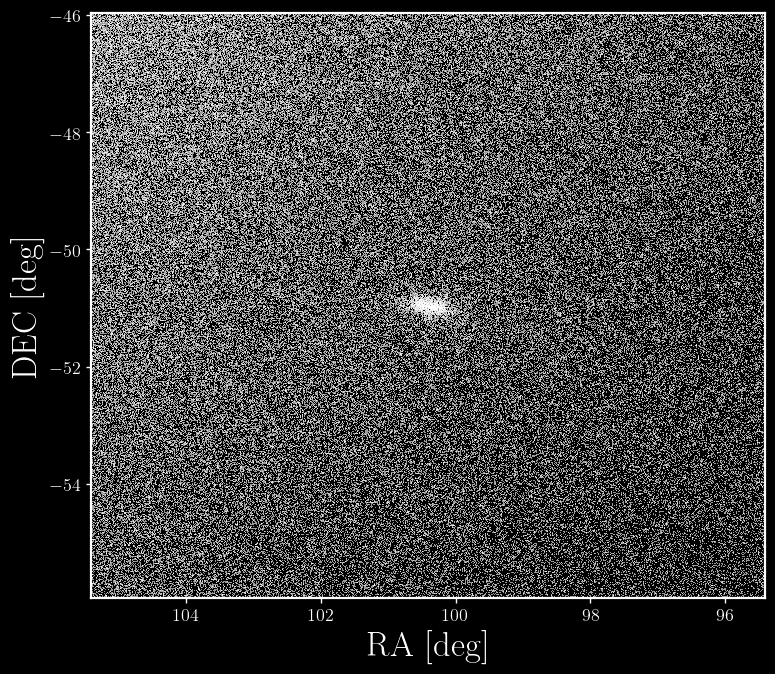

Overlay points matched by Gamma clusters in PM space: 2282/2358
TPR: 0.968


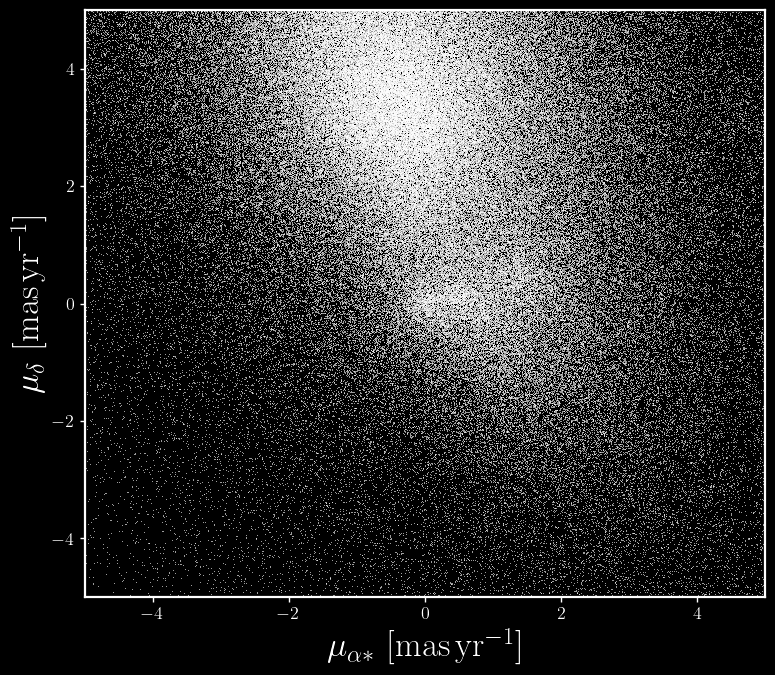

In [102]:

res_overlap = plot_Gamma_clusters_abs_with_kde_overlay_pm(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    overlay_df=tuc2_df,   # must contain ra_dr3, dec_dr3
    overlay_label=r"Dynamical validation [Battaglia et al.]",
    center_ra=None,
    plot_space="pos",
    center_dec=None,
    degsep=degsep,
    figsize=(8, 7),
    s_bg=0.5,
    alpha_bg=0.5,
    cluster_stats=out["cluster_stats"],
    # s_overlay=10,
        # Gamma display options
    gamma_as_points=False,
    gamma_as_kde=False,
    s_gamma=6,
    alpha_gamma=0.5,
    gamma_kde_levels=(0.3, 0.6, 0.95),
    gamma_min_pts_kde=5,

    # Overlay display options
    overlay_as_points=False,
    overlay_as_kde=False,
    s_overlay=6,
    alpha_overlay=0.5,
    overlay_kde_levels=(0.3, 0.6, 0.95),

    # Shared KDE settings
    kde_grid=250,
    title=r"",
    print_overlap=True,
)
plot_Gamma_clusters_abs_with_kde_overlay_pm(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    overlay_df=tuc2_df,
    cluster_stats=out["cluster_stats"],
    plot_space="pm",
    r_pmra_col="pmra",
    r_pmdec_col="pmdec",
    overlay_pmra_col="pmra_dr3",
    overlay_pmdec_col="pmdec_dr3",
    center_pmra=None,   # set if you want cyan guide lines
    center_pmdec=None,
    dpm=None,
    invert_x=False,

        figsize=(8, 7),
    s_bg=0.5,
    alpha_bg=0.5,
    # s_overlay=10,
        # Gamma display options
    gamma_as_points=False,
    gamma_as_kde=False,
    s_gamma=10,
    alpha_gamma=0.5,
    gamma_kde_levels=(0.3, 0.6, 0.95),
    gamma_min_pts_kde=5,

    # Overlay display options
    overlay_as_points=False,
    overlay_as_kde=False,
    s_overlay=6,
    alpha_overlay=0.5,
    overlay_kde_levels=(0.3, 0.6, 0.95),

    # Shared KDE settings
    kde_grid=250,
    title=r"",
    print_overlap=True,
)